# Data

In [ ]:

from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import matplotlib.pyplot as pltn
import seaborn as sns
import networkx as nx
import pickle
from scipy.stats import bootstrap, pearsonr
import os
%matplotlib inline

data = np.load('procdata/data.pkl', allow_pickle=True)
grep_data = np.load('procdata/grep_ageds.pkl', allow_pickle=True)


#Select sample for testing.
#data = data[data['age'] < 30]
grep_data = grep_data[grep_data['age'] < 30]
data=data.sample(n=1000, random_state=42)

# Reshape connectomes into 2D arrays 
connectomes = np.stack(data['connectome'].values)
connectomes_gr= np.stack(grep_data['connectome'].values)
df=pd.DataFrame(connectomes.reshape(connectomes.shape[0], -1))
df_gr=pd.DataFrame(connectomes_gr.reshape(connectomes_gr.shape[0], -1))

data['subject_id'] = np.arange(len(data))
grep_data['subject_id'] = np.arange(len(grep_data))

df.insert(0, 'subject_id', data['subject_id'].to_numpy())
df_gr.insert(0, 'subject_id', grep_data['subject_id'].to_numpy())
from helperfuncs import median_ci, bin_median_ci, fit_linear, graph_metrics, weight_greedy_nav


FileNotFoundError: [Errno 2] No such file or directory: 'procdata/data.pkl'

In [3]:
import numpy as np
data=np.load('procdata/data_with_metrics.pkl', allow_pickle=True)

In [4]:
data.columns

Index(['age', 'dataset', 'sex', 'connectome', 'decade', 'density', 'strength',
       'degree', 'Y_obs', 'kY_obs', 'Y_null', 'Ratio', 'C_unw', 'C_w',
       'comm_mean'],
      dtype='object')

In [120]:

# Save to CSV for ESNcpp
df.to_csv('ESNcpp/data/connectomes_sample.csv', index=False, header=True)
df_gr.to_csv('ESNcpp/data/connectomes_grep.csv', index=False, header=True)


In [3]:

# Import results from ESNcpp and merge with original data. This will be the general dataframe, though more can be incorporated later.
df_esn = pd.read_csv('ESNcpp/mc_null_results.csv') #analyzing null results for MC and MC bio for 300 subs with respect to MC in disparity null model. 
df=pd.merge(df_esn,data , on='subject_id')


df_esn_gr = pd.read_csv('ESNcpp/mc_null_results_gr.csv')
df_gr=pd.merge(df_esn_gr, grep_data, on='subject_id')

In [4]:
df.columns

Index(['subject_id', 'MC_Glob_Real', 'MC_Glob_BS', 'Ratio_Glob_BS',
       'MC_Bio_Real', 'MC_Bio_BS', 'Ratio_Bio_BS', 'MC_Glob_Uni',
       'Ratio_Glob_Uni', 'MC_Bio_Uni', 'Ratio_Bio_Uni', 'MC_Glob_Rsh',
       'Ratio_Glob_Rsh', 'MC_Bio_Rsh', 'Ratio_Bio_Rsh', 'age', 'dataset',
       'sex', 'connectome', 'density', 'strength', 'degree', 'Y_obs', 'kY_obs',
       'Y_null', 'Ratio', 'weight', 'C_unw', 'C_w', 'comm_mean'],
      dtype='str')

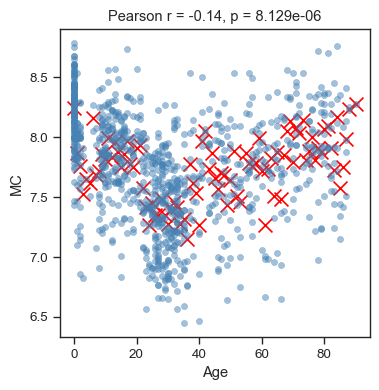

In [127]:
# Example and testing scatter
fig, ax = plt.subplots(1,1, figsize=(4,4))
task='MC_Glob_Real'
# Cálculo correcto y plot
df[task]# / df['density']
df_by_age = df.groupby('age')[task].mean().reset_index()

corr, p = pearsonr(df['age'], df[task])
    
ax.scatter(df_by_age['age'], df_by_age[task], 
               color='red', marker='x', s=100)
ax.set_xlabel('Age')
ax.set_ylabel('MC')
ax.set_title(f'Pearson r = {corr:.2f}, p = {p:.3e}')
sns.scatterplot(data=df, x='age', y=task, alpha=0.5, ax=ax, color='steelblue', edgecolor=None, s=20)
plt.savefig('results/ESN/age_vs_mc_deftrain.png', dpi=300, bbox_inches='tight')


# ESN performance and age as a function of disparity

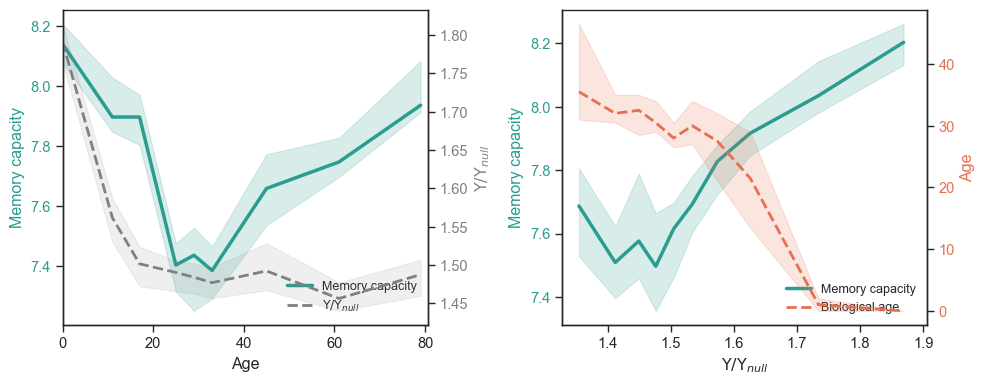

In [63]:
task= 'MC_Glob_Real' #or MC_Bio_Real

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

color_mc   = '#2a9d8f'
color_disp = 'gray'
color_age  = '#e76f51'


# ── Bin trajectories ──────────────────────────────────────────────────────────
traj_age   = bin_median_ci(df, 'age',   [task, 'Ratio'], q=10)
traj_ratio = bin_median_ci(df, 'Ratio', [task, 'age'],   q=10)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Left: MC and Ratio vs Age ─────────────────────────────────────────────────
ax_l  = axes[0]
ax_l2 = ax_l.twinx()

x = traj_age['age']

ax_l.plot(x, traj_age[task], color=color_mc, lw=2.5, label='Memory capacity')
ax_l.fill_between(x, traj_age[f'{task}_lo'], traj_age[f'{task}_hi'],
                  color=color_mc, alpha=0.18)

ax_l2.plot(x, traj_age['Ratio'], color=color_disp, lw=2, ls='--',
           label=r'$\Upsilon/\Upsilon_{null}$')
ax_l2.fill_between(x, traj_age['Ratio_lo'], traj_age['Ratio_hi'],
                   color=color_disp, alpha=0.12)

ax_l.set_xlabel('Age')
ax_l.set_ylabel('Memory capacity', color=color_mc)
ax_l2.set_ylabel(r'$\Upsilon/\Upsilon_{null}$', color=color_disp)
ax_l.tick_params(axis='y', labelcolor=color_mc)
ax_l2.tick_params(axis='y', labelcolor=color_disp)
ax_l.set_xlim(x.min() * 0.98, x.max() * 1.02)

lines1, labels1 = ax_l.get_legend_handles_labels()
lines2, labels2 = ax_l2.get_legend_handles_labels()
ax_l.legend(lines1 + lines2, labels1 + labels2, frameon=False,
            loc='lower right', fontsize=9)
sns.despine(ax=ax_l, right=False)

# ── Right: MC and Age vs Ratio ────────────────────────────────────────────────
ax_r  = axes[1]
ax_r2 = ax_r.twinx()

x = traj_ratio['Ratio']

ax_r.plot(x, traj_ratio[task], color=color_mc, lw=2.5, label='Memory capacity')
ax_r.fill_between(x, traj_ratio[f'{task}_lo'], traj_ratio[f'{task}_hi'],
                  color=color_mc, alpha=0.18)

ax_r2.plot(x, traj_ratio['age'], color=color_age, lw=2, ls='--',
           label='Biological age')
ax_r2.fill_between(x, traj_ratio['age_lo'], traj_ratio['age_hi'],
                   color=color_age, alpha=0.18)

ax_r.set_xlabel(r'$\Upsilon/\Upsilon_{null}$')
ax_r.set_ylabel('Memory capacity', color=color_mc)
ax_r2.set_ylabel('Age', color=color_age)
ax_r.tick_params(axis='y', labelcolor=color_mc)
ax_r2.tick_params(axis='y', labelcolor=color_age)
ax_r.set_xlim(x.min() * 0.98, x.max() * 1.02)

lines1, labels1 = ax_r.get_legend_handles_labels()
lines2, labels2 = ax_r2.get_legend_handles_labels()
ax_r.legend(lines1 + lines2, labels1 + labels2, frameon=False,
            loc='lower right', fontsize=9)
sns.despine(ax=ax_r, right=False)

plt.tight_layout()
plt.savefig('results/ESN/mc_disparity_age.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# Comparisson plot humans + grep + elegans

Saved.


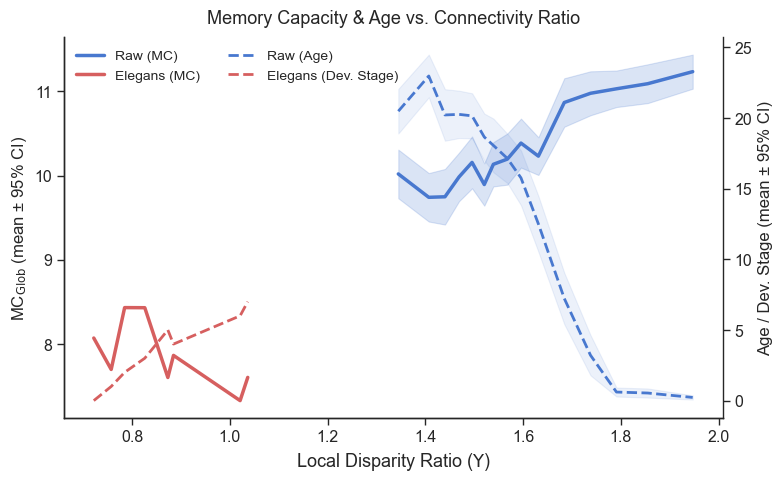

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

sns.set_theme(style="ticks", context="paper", font_scale=1.3)

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────

# --- Raw ---
data_raw = np.load('procdata/data.pkl', allow_pickle=True)
data_raw = data_raw[data_raw['age'] < 30].sample(n=1000, random_state=42)
data_raw = data_raw.reset_index(drop=True)
data_raw['subject_id'] = np.arange(len(data_raw))
df_esn_raw = pd.read_csv('ESNcpp/task_results.txt')
df_raw = pd.merge(df_esn_raw, data_raw, on='subject_id')


# --- Elegans ---
with open('procdata/data_elegans.pkl', 'rb') as f:
    data_elegans, _ = pickle.load(f)
df_esn_eleg = pd.read_csv('ESNcpp/task_results_celegans.txt')
if 'Age' in df_esn_eleg.columns:
    df_esn_eleg.rename(columns={'Age': 'subject_id'}, inplace=True)
df_eleg = pd.merge(df_esn_eleg, data_elegans, on='subject_id')

# ─────────────────────────────────────────────
# 2. BIN & AGGREGATE
# ─────────────────────────────────────────────

def bin_stats(df, x_col='Ratio', y_cols=None, n_bins=15):
    df = df[[x_col] + y_cols].dropna().copy()
    df['bin'] = pd.qcut(df[x_col], q=n_bins, duplicates='drop')
    grouped = df.groupby('bin', observed=True)
    result = grouped[x_col].mean().rename('x_mid').reset_index()
    for col in y_cols:
        agg = grouped[col].agg(['mean', 'std', 'count'])
        result[f'{col}_mean'] = agg['mean'].values
        result[f'{col}_ci']   = (1.96 * agg['std'] / np.sqrt(agg['count'])).values
    return result

agg_raw  = bin_stats(df_raw,  y_cols=['MC_Glob', 'age'], n_bins=15)
agg_eleg = bin_stats(df_eleg, y_cols=['MC_Glob', 'subject_id'], n_bins=8)

# ─────────────────────────────────────────────
# 3. PLOT
# ─────────────────────────────────────────────

colors = {'Raw': '#4878cf', 'Grep': '#3a9e5f', 'Elegans': '#d65f5f'}

fig, ax_mc = plt.subplots(figsize=(8, 5))
ax_age = ax_mc.twinx()

def plot_band(ax, agg, x_col, y_col, color, lw=2.5, ls='-', label=None, alpha=0.2):
    x   = agg[x_col]
    y   = agg[f'{y_col}_mean']
    err = agg[f'{y_col}_ci']
    ax.plot(x, y, color=color, lw=lw, ls=ls, label=label)
    ax.fill_between(x, y - err, y + err, color=color, alpha=alpha)

# MC_Glob — solid lines, left axis
plot_band(ax_mc,  agg_raw,  'x_mid', 'MC_Glob',    colors['Raw'],    label='Raw (MC)')
plot_band(ax_mc,  agg_eleg, 'x_mid', 'MC_Glob',    colors['Elegans'],label='Elegans (MC)')

# Age — dashed lines, right axis
plot_band(ax_age, agg_raw,  'x_mid', 'age',        colors['Raw'],    lw=2, ls='--', label='Raw (Age)',          alpha=0.10)
plot_band(ax_age, agg_eleg, 'x_mid', 'subject_id', colors['Elegans'],lw=2, ls='--', label='Elegans (Dev. Stage)', alpha=0.10)

# ── Axes labels ──────────────────────────────
ax_mc.set_xlabel(r'Local Disparity Ratio ($\Upsilon$)', fontsize=13)
ax_mc.set_ylabel(r'MC$_{\mathrm{Glob}}$ (mean ± 95% CI)', fontsize=12)
ax_age.set_ylabel('Age / Dev. Stage (mean ± 95% CI)', fontsize=12)

# ── Combined legend ──────────────────────────
handles_mc,  labels_mc  = ax_mc.get_legend_handles_labels()
handles_age, labels_age = ax_age.get_legend_handles_labels()
ax_mc.legend(handles_mc + handles_age, labels_mc + labels_age,
             frameon=False, fontsize=10, loc='upper left',
             ncol=2, handlelength=2)

sns.despine(ax=ax_mc,  right=False)
sns.despine(ax=ax_age, left=False)
plt.title('Memory Capacity & Age vs. Connectivity Ratio', fontsize=13, pad=10)
plt.tight_layout()

plt.savefig('results/ESN/mc_age_ratio_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('results/ESN/mc_age_ratio_comparison.png', dpi=300, bbox_inches='tight')
print("Saved.")
plt.show()

# Explained variance

In [12]:
"""
Variance explained table: how much does Disparity (Ratio) and MC_Glob
explain Age, and how much does Disparity explain MC_Glob?

Structure mirrors Mijalkov et al. (2025, Nat Commun) Table approach:
  - Linear models with sex as covariate
  - Reports R², ΔR² (over sex-only baseline), p-value for predictor
  - Three datasets: Raw, Grep, Elegans
  - Three model types:
      (1) Age ~ sex + Ratio          → Disparity predicts Age
      (2) Age ~ sex + MC_Glob         → MC predicts Age      (replication of paper)
      (3) Age ~ sex + Ratio + MC_Glob→ Both: does disparity add over MC?
      (4) MC_Glob ~ sex + Ratio      → Disparity predicts MC (mechanistic link)
"""

import numpy as np
import pandas as pd
import pickle
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────

data_raw = np.load('procdata/data.pkl', allow_pickle=True)
data_raw = data_raw[data_raw['age'] < 30].sample(n=1000, random_state=42).reset_index(drop=True)
data_raw['subject_id'] = np.arange(len(data_raw))
df_raw = pd.merge(pd.read_csv('ESNcpp/task_results.txt'), data_raw, on='subject_id')

grep_data = np.load('procdata/grep_ageds.pkl', allow_pickle=True)
grep_data = grep_data[grep_data['age'] < 30].reset_index(drop=True)
grep_data['subject_id'] = np.arange(len(grep_data))
df_grep = pd.merge(pd.read_csv('ESNcpp/task_results_gr.txt'), grep_data, on='subject_id')

with open('procdata/data_elegans.pkl', 'rb') as f:
    data_elegans, _ = pickle.load(f)
df_esn_eleg = pd.read_csv('ESNcpp/task_results_celegans.txt')
if 'Age' in df_esn_eleg.columns:
    df_esn_eleg.rename(columns={'Age': 'subject_id'}, inplace=True)
df_eleg = pd.merge(df_esn_eleg, data_elegans, on='subject_id')

# Map elegans: 'subject_id' acts as developmental stage proxy for 'age'
df_eleg = df_eleg.copy()
df_eleg['age'] = df_eleg['subject_id']   # developmental stage as ordinal age proxy

# Encode sex as dummy if present, else use zeros
for df in [df_raw, df_grep, df_eleg]:
    if 'sex' in df.columns:
        df['sex_enc'] = pd.Categorical(df['sex']).codes.astype(float)
    else:
        df['sex_enc'] = 0.0

datasets = {
    'Raw (human, n={})'.format(len(df_raw)):   df_raw,
    'Grep (human, n={})'.format(len(df_grep)): df_grep,
    'Elegans (dev. stage, n={})'.format(len(df_eleg)): df_eleg,
}

# ─────────────────────────────────────────────
# 2. FIT MODELS & EXTRACT STATS
# ─────────────────────────────────────────────


def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

rows = []
for ds_name, df in datasets.items():
    df = df[['age', 'sex_enc', 'Ratio', 'MC_Glob']].dropna()
    y_age  = df['age'].values.astype(float)
    y_mc   = df['MC_Glob'].values.astype(float)
    sex    = df['sex_enc'].values
    disp   = df['Ratio'].values
    mc     = df['MC_Glob'].values

    # Baseline: age ~ sex
    r2_base_age, _ = fit_linear(y_age,  sex.reshape(-1,1))
    r2_base_mc,  _ = fit_linear(y_mc,   sex.reshape(-1,1))

    # Model 1: age ~ sex + disparity
    r2_1, p_1 = fit_linear(y_age, np.column_stack([sex, disp]))
    delta_1 = r2_1 - r2_base_age

    # Model 2: age ~ sex + MC_Glob
    r2_2, p_2 = fit_linear(y_age, np.column_stack([sex, mc]))
    delta_2 = r2_2 - r2_base_age

    # Model 3: age ~ sex + disparity + MC_Glob
    r2_3, p_3 = fit_linear(y_age, np.column_stack([sex, disp, mc]))
    delta_3 = r2_3 - r2_base_age

    # Model 4: MC ~ sex + disparity
    r2_4, p_4 = fit_linear(y_mc, np.column_stack([sex, disp]))
    delta_4 = r2_4 - r2_base_mc

    # Pearson r for readability
    r_disp_age, p_r1 = stats.pearsonr(disp, y_age)
    r_mc_age,   p_r2 = stats.pearsonr(mc,   y_age)
    r_disp_mc,  p_r3 = stats.pearsonr(disp, y_mc)

    rows.append({
        'Dataset': ds_name,
        'Model': 'Age ~ Disparity',
        'r': f'{r_disp_age:.3f}',
        'R²': f'{r2_1:.3f}',
        'ΔR² (over sex)': f'{delta_1:.3f}',
        'p (model)': f'{p_1:.2e}',
        'Sig': stars(p_1),
    })
    rows.append({
        'Dataset': ds_name,
        'Model': 'Age ~ MC_Glob',
        'r': f'{r_mc_age:.3f}',
        'R²': f'{r2_2:.3f}',
        'ΔR² (over sex)': f'{delta_2:.3f}',
        'p (model)': f'{p_2:.2e}',
        'Sig': stars(p_2),
    })
    rows.append({
        'Dataset': ds_name,
        'Model': 'Age ~ Disparity + MC_Glob',
        'r': '—',
        'R²': f'{r2_3:.3f}',
        'ΔR² (over sex)': f'{delta_3:.3f}',
        'p (model)': f'{p_3:.2e}',
        'Sig': stars(p_3),
    })
    rows.append({
        'Dataset': ds_name,
        'Model': 'MC_Glob ~ Disparity',
        'r': f'{r_disp_mc:.3f}',
        'R²': f'{r2_4:.3f}',
        'ΔR² (over sex)': f'{delta_4:.3f}',
        'p (model)': f'{p_4:.2e}',
        'Sig': stars(p_4),
    })
    rows.append({'Dataset': '', 'Model': '', 'r': '', 'R²': '', 'ΔR² (over sex)': '', 'p (model)': '', 'Sig': ''})

result_df = pd.DataFrame(rows)

# ─────────────────────────────────────────────
# 3. PRINT & SAVE
# ─────────────────────────────────────────────
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)
print(result_df.to_string(index=False))

result_df.to_csv('results/ESN/variance_explained_table_deftrain.csv', index=False)
print("\nSaved to results/ESN/variance_explained_table_deftrain.csv")

                  Dataset                     Model      r    R² ΔR² (over sex) p (model)  Sig
      Raw (human, n=1000)           Age ~ Disparity -0.746 0.557          0.557  0.00e+00  ***
      Raw (human, n=1000)             Age ~ MC_Glob -0.431 0.187          0.186  0.00e+00  ***
      Raw (human, n=1000) Age ~ Disparity + MC_Glob      — 0.584          0.583  0.00e+00  ***
      Raw (human, n=1000)       MC_Glob ~ Disparity  0.377 0.142          0.142  0.00e+00  ***
                                                                                              
       Grep (human, n=57)           Age ~ Disparity -0.695 0.483          0.483  1.86e-08  ***
       Grep (human, n=57)             Age ~ MC_Glob -0.256 0.065          0.065  1.61e-01 n.s.
       Grep (human, n=57) Age ~ Disparity + MC_Glob      — 0.511          0.511  2.54e-08  ***
       Grep (human, n=57)       MC_Glob ~ Disparity  0.129 0.017          0.017  6.35e-01 n.s.
                                                  

In [5]:
"""
Confound Horse-Race: which network metric best predicts MC_Glob?

Assumes `df` is already in memory with columns:
    kY_obs, MC_Glob, connectome, age

Metrics (Suarez 2021, Damicelli 2022, Jaeger 2001, Mijalkov 2025,
         Barjuan et al. 2024):
  1–14  standard graph metrics
  15    navigability  – weight-based greedy routing success rate
                        (Barjuan et al. 2024: λ=0 limit of HWSD protocol)
All connectomes normalised to ρ = 0.99 (Suarez et al.)
"""

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='ticks', context='paper', font_scale=1.2)
RHO     = 0.99
N_PAIRS = 400   # pairs sampled per connectome for navigability (speed/accuracy trade-off)
TIMEOUT = 2 * 100  # max steps = 2 × N_nodes (generous)

assert 'connectome' in df.columns
assert 'MC_Glob'    in df.columns
assert 'kY_obs'     in df.columns

df_work        = df.copy().reset_index(drop=True)
connectomes_all = np.stack(df_work['connectome'].values)
print(f"Using df: N = {len(df_work)} subjects, connectome shape: {connectomes_all[0].shape}")

import os
METRICS_CACHE = 'results/ESN/confound_metrics_cache.pkl'
if os.path.exists(METRICS_CACHE):
    df_metrics = pd.read_pickle(METRICS_CACHE)
    print(f"Loaded df_metrics from cache ({len(df_metrics)} rows)")
else:
    metrics_list = [graph_metrics(A, n_pairs=N_PAIRS, rho=RHO) for A in tqdm(connectomes_all, ncols=70)]
    df_metrics   = pd.DataFrame(metrics_list).reset_index(drop=True)
    os.makedirs('results/ESN', exist_ok=True)
    df_metrics.to_pickle(METRICS_CACHE)
    print(f"Computed and cached → {METRICS_CACHE}")

CONFOUNDS = list(df_metrics.columns)   # now 15 metrics
df_full = pd.concat([
    df_work[['kY_obs', 'MC_Glob', 'age']].reset_index(drop=True),
    df_metrics
], axis=1).dropna()
print(f"Final N = {len(df_full)}, confounds: {CONFOUNDS}")

# ─────────────────────────────────────────────────────────────────────────────
# LABELS dict  (used by both horse-race and partial-r cells below)
# ─────────────────────────────────────────────────────────────────────────────
LABELS = {
    'kY_obs':            'Disparity (Υ)  ◀',
    'density':           'Density',
    'mean_weight':       'Mean weight',
    'weight_var':        'Weight variance',
    'spectral_radius':   'Spectral radius (λ₁)',
    'mean_degree':       'Mean degree',
    'degree_var':        'Degree variance',
    'global_efficiency': 'Global efficiency',
    'clustering':        'Clustering coeff.',
    'modularity':        'Modularity (Q)',
    'assortativity':     'Assortativity',
    'betweenness':       'Betweenness centr.',
    'transitivity':      'Transitivity',
    'rich_club':         'Rich-club coeff.',
    'communicability':   'Communicability',
    'navigability':      'Navigability (SR)',   # ← NEW
}

# ─────────────────────────────────────────────────────────────────────────────
# HORSE-RACE  R²  (MC_Glob ~ each predictor)
# ─────────────────────────────────────────────────────────────────────────────
ALL_PREDICTORS = ['kY_obs'] + CONFOUNDS
rows = []
for pred in ALL_PREDICTORS:
    sub      = df_full[['MC_Glob', pred]].dropna()
    r, p     = pearsonr(sub[pred], sub['MC_Glob'])
    rows.append(dict(predictor=pred, label=LABELS[pred],
                     r=r, R2=r**2, p=p,
                     sig='***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.')),
                     is_disp=(pred == 'kY_obs')))

horse_df = pd.DataFrame(rows).sort_values('R2', ascending=True)

# ─────────────────────────────────────────────────────────────────────────────
# PARTIAL r  (kY_obs ↔ MC_Glob | confound_i)
# ─────────────────────────────────────────────────────────────────────────────
def partial_r(df_, x, y, cov):
    sub = df_[[x, y, cov]].dropna()
    def resid(a, b):
        c = np.polyfit(sub[b], sub[a], 1)
        return sub[a].values - np.polyval(c, sub[b].values)
    return pearsonr(resid(x, cov), resid(y, cov))

r0, p0 = pearsonr(df_full['kY_obs'], df_full['MC_Glob'])
partial_rows = [dict(label='Zero-order r', r_partial=r0, p=p0,
                     sig='***' if p0<0.001 else '**' if p0<0.01 else '*' if p0<0.05 else 'n.s.',
                     is_zero=True)]

for conf in CONFOUNDS:
    rp, pp = partial_r(df_full, 'kY_obs', 'MC_Glob', conf)
    partial_rows.append(dict(
        label    = f'| {LABELS[conf]}',
        r_partial= rp, p=pp,
        sig      = '***' if pp<0.001 else ('**' if pp<0.01 else ('*' if pp<0.05 else 'n.s.')),
        is_zero  = False,
    ))

part_df = pd.DataFrame(partial_rows)
print("\nDone. Run the plot cell next.")

Using df: N = 1000 subjects, connectome shape: (90, 90)
Computing graph metrics + navigability…


100%|█████████████████████████████| 1000/1000 [00:53<00:00, 18.59it/s]

Final N = 1000, confounds: ['density', 'mean_weight', 'weight_var', 'spectral_radius', 'mean_degree', 'degree_var', 'global_efficiency', 'clustering', 'modularity', 'assortativity', 'betweenness', 'transitivity', 'rich_club', 'communicability', 'navigability']

Done. Run the plot cell next.



── R² horse-race (MC_Glob ~ predictor) ──
               label         r       R2            p  sig
     Communicability  0.536133 0.287438 1.699559e-75  ***
   Clustering coeff.  0.475632 0.226226 1.386929e-57  ***
    Disparity (Υ)  ◀  0.377041 0.142160 3.917448e-35  ***
         Mean degree  0.252183 0.063596 5.681610e-16  ***
             Density  0.252183 0.063596 5.681610e-16  ***
         Mean weight  0.239068 0.057154 1.831887e-14  ***
   Global efficiency  0.237269 0.056297 2.903487e-14  ***
        Transitivity  0.233279 0.054419 7.957716e-14  ***
      Modularity (Q)  0.212856 0.045307 1.040790e-11  ***
Spectral radius (λ₁) -0.202701 0.041088 9.851609e-11  ***
    Rich-club coeff.  0.163861 0.026850 1.883310e-07  ***
     Degree variance  0.129563 0.016787 3.967493e-05  ***
       Assortativity  0.089230 0.007962 4.745639e-03   **
  Betweenness centr.  0.037699 0.001421 2.336211e-01 n.s.
     Weight variance  0.004375 0.000019 8.901103e-01 n.s.

── Partial r(Ratio, MC_Glob 

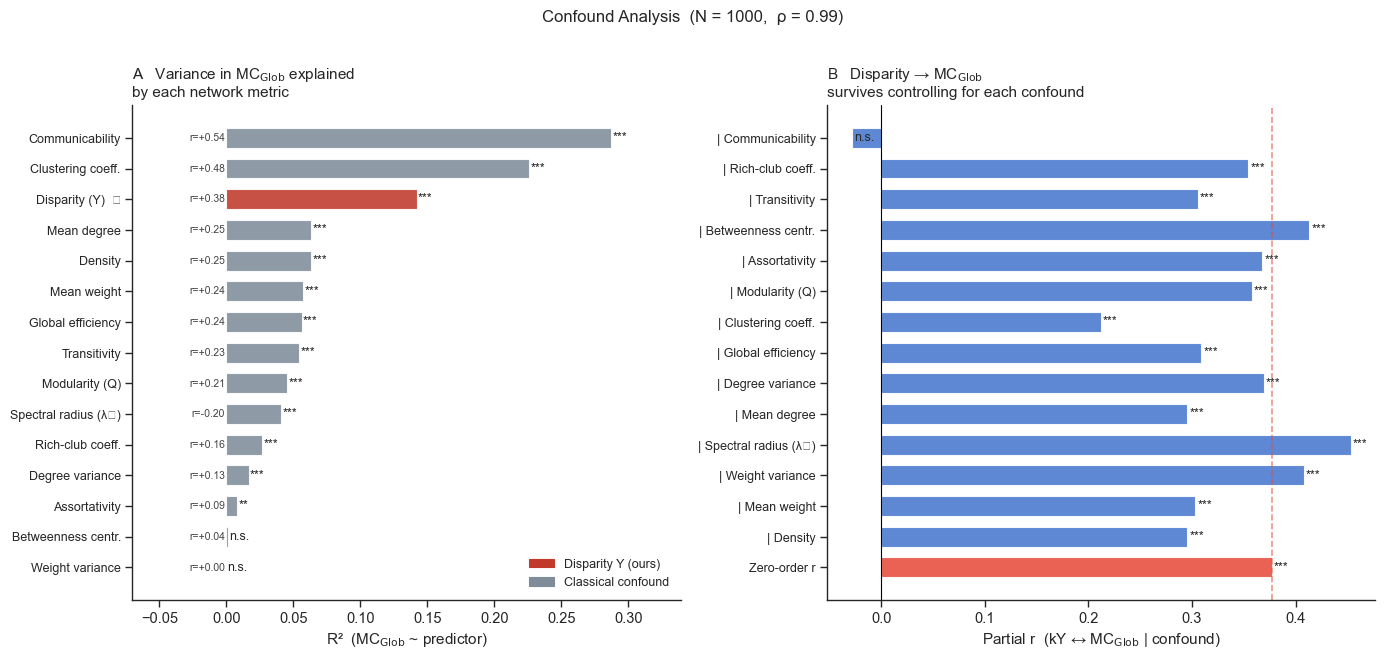

In [151]:

# ─────────────────────────────────────────────
# 2. HORSE-RACE: R² of MC_Glob ~ each metric
# ─────────────────────────────────────────────
ALL_PREDICTORS = ['Ratio'] + CONFOUNDS

LABELS = {
    'Ratio':           'Disparity (Υ)  ◀',
    'density':          'Density',
    'mean_weight':      'Mean weight',
    'weight_var':       'Weight variance',
    'spectral_radius':  'Spectral radius (λ₁)',
    'mean_degree':      'Mean degree',
    'degree_var':       'Degree variance',
    'global_efficiency':'Global efficiency',
    'clustering':       'Clustering coeff.',
    'modularity':       'Modularity (Q)',
    'assortativity':    'Assortativity',
    'betweenness':      'Betweenness centr.',
    'transitivity':     'Transitivity',
    'rich_club':        'Rich-club coeff.',
    'communicability':  'Communicability',
}

rows = []
for pred in ALL_PREDICTORS:
    sub = df_full[['MC_Glob', pred]].dropna()
    y   = sub['MC_Glob'].values
    x   = sub[pred].values
    r, p = pearsonr(x, y)
    r2   = r ** 2
    rows.append(dict(
        predictor = pred,
        label     = LABELS[pred],
        r         = r,
        R2        = r2,
        p         = p,
        sig       = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')),
        is_disp   = (pred == 'Ratio'),
    ))

horse_df = pd.DataFrame(rows).sort_values('R2', ascending=True)

# ─────────────────────────────────────────────
# 3. PARTIAL r(Ratio, MC_Glob | metric_i)
#    robust version (no pingouin CI dependency)
# ─────────────────────────────────────────────
def partial_r(df_, x, y, cov):
    """Partial correlation x~y controlling for cov via residuals."""
    sub = df_[[x, y, cov]].dropna()
    def resid(a, b):
        from numpy.polynomial import polynomial as P
        c = np.polyfit(sub[b], sub[a], 1)
        return sub[a].values - np.polyval(c, sub[b].values)
    rx = resid(x, cov)
    ry = resid(y, cov)
    r, p = pearsonr(rx, ry)
    return r, p

partial_rows = []
r0, p0 = pearsonr(df_full['Ratio'], df_full['MC_Glob'])
partial_rows.append(dict(label='Zero-order r', r_partial=r0, p=p0,
                         sig='***' if p0<0.001 else '**' if p0<0.01 else '*' if p0<0.05 else 'n.s.',
                         is_zero=True))

for conf in CONFOUNDS:
    r_p, p_p = partial_r(df_full, 'Ratio', 'MC_Glob', conf)
    partial_rows.append(dict(
        label     = f'| {LABELS[conf]}',
        r_partial = r_p,
        p         = p_p,
        sig       = '***' if p_p<0.001 else ('**' if p_p<0.01 else ('*' if p_p<0.05 else 'n.s.')),
        is_zero   = False,
    ))

part_df = pd.DataFrame(partial_rows)

# ─────────────────────────────────────────────
# 4. FIGURE: two-panel
# ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

# ── Panel A: R² horse-race ───────────────────
colors_bar = ['#c0392b' if r else '#7f8c9a' for r in horse_df['is_disp']]
bars = ax1.barh(range(len(horse_df)), horse_df['R2'],
                color=colors_bar, height=0.65, alpha=0.88)

for i, (_, row) in enumerate(horse_df.iterrows()):
    ax1.text(row['R2'] + 0.001, i, row['sig'], va='center', fontsize=9)
    ax1.text(-0.001, i, f"r={row['r']:+.2f}", va='center', ha='right',
             fontsize=7.5, color='#444')

ax1.set_yticks(range(len(horse_df)))
ax1.set_yticklabels(horse_df['label'], fontsize=9)
ax1.set_xlabel('R²  (MC$_\\mathrm{Glob}$ ~ predictor)', fontsize=11)
ax1.set_title('A   Variance in MC$_\\mathrm{Glob}$ explained\nby each network metric',
              fontsize=11, loc='left')
ax1.set_xlim(-0.07, horse_df['R2'].max() * 1.18)

patch_disp = mpatches.Patch(color='#c0392b', label='Disparity Υ (ours)')
patch_conf = mpatches.Patch(color='#7f8c9a', label='Classical confound')
ax1.legend(handles=[patch_disp, patch_conf], frameon=False,
           fontsize=9, loc='lower right')
sns.despine(ax=ax1)

# ── Panel B: partial r(Ratio, MC | confound) ─
part_plot = part_df.copy()
cols_b = ['#e74c3c' if r else '#4878cf' for r in part_plot['is_zero']]
ax2.barh(range(len(part_plot)), part_plot['r_partial'],
         color=cols_b, height=0.65, alpha=0.88)

for i, (_, row) in enumerate(part_plot.iterrows()):
    ax2.text(row['r_partial'] + 0.002, i, row['sig'], va='center', fontsize=9)

ax2.set_yticks(range(len(part_plot)))
ax2.set_yticklabels(part_plot['label'], fontsize=9)
ax2.axvline(0,    color='black',  lw=0.8)
ax2.axvline(r0,   color='#e74c3c', lw=1.2, ls='--', alpha=0.6)
ax2.set_xlabel('Partial r  (kΥ ↔ MC$_\\mathrm{Glob}$ | confound)',
               fontsize=11)
ax2.set_title('B   Disparity → MC$_\\mathrm{Glob}$\nsurvives controlling for each confound',
              fontsize=11, loc='left')
sns.despine(ax=ax2)

plt.suptitle(f'Confound Analysis  (N = {len(df_full)},  ρ = {RHO})',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('results/ESN/confound_horserace_deftrain.pdf', dpi=300, bbox_inches='tight')
plt.savefig('results/ESN/confound_horserace_deftrain.png', dpi=300, bbox_inches='tight')

# ── Print table ──────────────────────────────
print("\n── R² horse-race (MC_Glob ~ predictor) ──")
print(horse_df[['label','r','R2','p','sig']].sort_values('R2', ascending=False).to_string(index=False))
horse_df.to_csv('results/ESN/confound_horserace_deftrain.csv', index=False)

print("\n── Partial r(Ratio, MC_Glob | confound) ──")
print(part_df.to_string(index=False))
part_df.to_csv('results/ESN/confound_partial_r_deftrain.csv', index=False)

print("\nDone.")
plt.show()

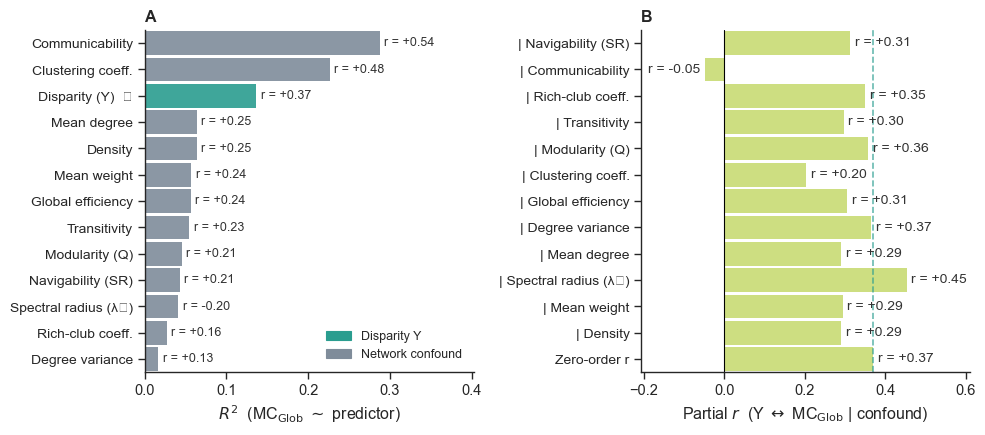

In [10]:
"""
Plot cell — two-panel confound figure.
Requires horse_df, part_df, LABELS, CONFOUNDS from the metrics cell above.
"""

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

color_disp    = '#2a9d8f'
color_conf    = '#7f8c9a'
color_partial = '#a5c41a'

FIG_W, FIG_H = 10, 4.5

# ── filter: keep only R² ≥ 0.05 ─────────────────────────────────────────────
horse_plot = horse_df[horse_df['R2'] >= 0.01].copy()   # sorted ascending

kept_predictors = set(horse_plot['predictor'])
part_plot = part_df[
    part_df['label'].isin(
        ['Zero-order r'] +
        [f'| {LABELS[c]}' for c in CONFOUNDS if c in kept_predictors]
    )
].copy()

n_a = len(horse_plot)
n_b = len(part_plot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# ── Panel A: R² horse-race ────────────────────────────────────────────────────
colors_a = [color_disp if v else color_conf for v in horse_plot['is_disp']]
ax1.barh(range(n_a), horse_plot['R2'],
         color=colors_a, height=0.9, alpha=0.90, linewidth=0)

r2_max = horse_plot['R2'].max()
for i, (_, row) in enumerate(horse_plot.iterrows()):
    ax1.text(row['R2'] + r2_max * 0.02, i,
             f"r = {row['r']:+.2f}",
             va='center', fontsize=9, color='#333333')

ax1.set_yticks(range(n_a))
ax1.set_yticklabels(horse_plot['label'], fontsize=10)
ax1.set_xlabel(r'$R^2$  (MC$_\mathrm{Glob}$ $\sim$ predictor)')
ax1.set_xlim(0, r2_max * 1.40)
ax1.set_ylim(-0.5, n_a - 0.5)
ax1.set_title('A', loc='left', fontweight='bold')

patch_disp = mpatches.Patch(color=color_disp, label='Disparity Υ')
patch_conf = mpatches.Patch(color=color_conf, label='Network confound')
ax1.legend(handles=[patch_disp, patch_conf], frameon=False, fontsize=9)
sns.despine(ax=ax1)

# ── Panel B: partial r(Υ, MC | confound) ────────────────────────────────────
ax2.barh(range(n_b), part_plot['r_partial'],
         color=color_partial, height=0.9, alpha=0.55, linewidth=0)

x_abs   = part_plot['r_partial'].abs().max()
offset  = x_abs * 0.025

for i, (_, row) in enumerate(part_plot.iterrows()):
    rp = row['r_partial']
    ha = 'left' if rp >= 0 else 'right'
    xp = rp + offset if rp >= 0 else rp - offset
    ax2.text(xp, i, f"r = {rp:+.2f}",
             va='center', ha=ha, fontsize=10, color='#333333')

ax2.set_yticks(range(n_b))
ax2.set_yticklabels(part_plot['label'], fontsize=10)
ax2.axvline(0,  color='black', lw=0.8)
ax2.axvline(r0, color=color_disp, lw=1.2, ls='--', alpha=0.7,
            label=f'Zero-order r = {r0:.2f}')
ax2.set_xlabel(r'Partial $r$  (Υ $\leftrightarrow$ MC$_\mathrm{Glob}$ | confound)')
ax2.set_ylim(-0.5, n_b - 0.5)
ax2.set_xlim(part_plot['r_partial'].min() - x_abs * 0.35,
             part_plot['r_partial'].max() + x_abs * 0.35)
ax2.set_title('B', loc='left', fontweight='bold')
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('results/ESN/confound_horserace_deftrain.pdf',
            dpi=300, bbox_inches='tight', transparent=True)
plt.savefig('results/ESN/confound_horserace_deftrain.png',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

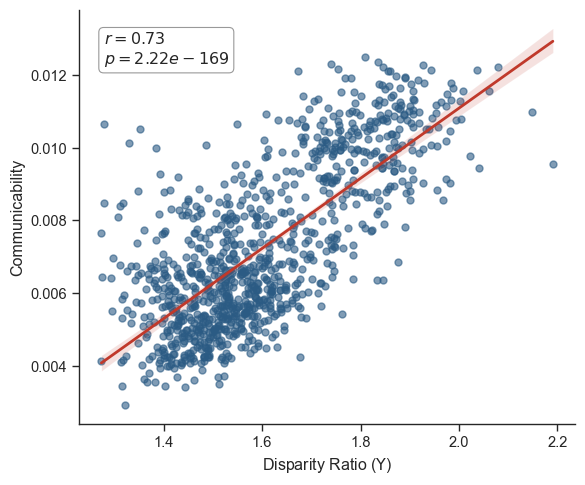

In [217]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Set paper style as requested
sns.set_theme(style='ticks', context='paper', font_scale=1.2)

fig, ax = plt.subplots(figsize=(6, 5))

# Extract variables
x = df_full['Ratio']
y = df_full['communicability']

# Calculate correlation for annotations
r, p = pearsonr(x, y)

# Plot without title (as per your guidelines)
sns.regplot(
    x=x, 
    y=y, 
    scatter_kws={'alpha': 0.6, 's': 25, 'color': '#2b5b84'}, 
    line_kws={'color': '#c0392b', 'lw': 2},
    ax=ax
)

# Labeling
ax.set_xlabel(r'Disparity Ratio ($\Upsilon$)')
ax.set_ylabel('Communicability')

# Add correlation text inside the plot
ax.text(0.05, 0.95, f'$r = {r:.2f}$\n$p = {p:.2e}$', 
        transform=ax.transAxes, va='top', ha='left', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

sns.despine()
plt.tight_layout()
plt.savefig('results/ESN/disparity_vs_communicability.pdf', dpi=300)
plt.show()

# Replication mijalkov

In [73]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- 1. FUNCIÓN DE UMBRALIZACIÓN PROPORCIONAL ---
def proportional_threshold(adj, density=0.15):
    """
    Retiene solo el top X% (density) de las conexiones más fuertes.
    """
    N = adj.shape[0]
    # Extraer el triángulo superior para no duplicar enlaces
    upper_tri = adj[np.triu_indices_from(adj, k=1)]
    
    # Calcular cuántos enlaces queremos mantener
    max_edges = int(N * (N - 1) / 2)
    edges_to_keep = int(max_edges * density)
    
    # Encontrar el valor de corte (threshold)
    threshold_val = np.sort(upper_tri)[-edges_to_keep]
    
    # Aplicar umbral: mantener pesos si superan el corte, si no 0
    adj_thresh = np.where(adj >= threshold_val, adj, 0.0)
    
    return adj_thresh

# --- 2. CARGA Y FILTRADO (Cam-CAN, Edad > 30) ---
old_data = np.load('procdata/data.pkl', allow_pickle=True)

# Asumo que la columna se llama 'dataset', ajusta si es distinto
old_data = old_data[(old_data['dataset'] == 8)]

# Coger todos los sujetos disponibles (o haz un sample si son demasiados para C++)
old_data = old_data.sample(n=200, random_state=42) 

print(f"Sujetos Cam-CAN (Dataset 8) mayores de 30 años: {len(old_data)}")

# --- 3. EXTRACCIÓN Y APLICACIÓN DEL UMBRAL ---
connectomes_old = np.stack(old_data['connectome'].values)
connectomes_thresh = np.zeros_like(connectomes_old)

for i in range(connectomes_old.shape[0]):
    connectomes_thresh[i] = proportional_threshold(connectomes_old[i], density=0.15)

# --- 4. EXPORTACIÓN PARA C++ ---
df_old = pd.DataFrame(connectomes_thresh.reshape(connectomes_thresh.shape[0], -1))

# Asignar subject_id limpio
old_data['subject_id'] = np.arange(len(old_data))
df_old.insert(0, 'subject_id', old_data['subject_id'].to_numpy())

df_old.to_csv('ESNcpp/data/connectomes_thresh_camcan.csv', index=False, header=True)
print("Matriz umbralizada exportada a 'connectomes_thresh_camcan.csv'.")

Sujetos Cam-CAN (Dataset 8) mayores de 30 años: 200
Matriz umbralizada exportada a 'connectomes_thresh_camcan.csv'.


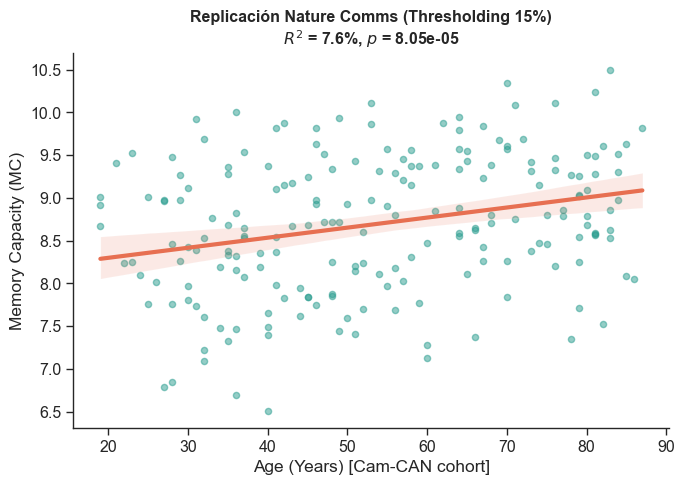

In [74]:
# --- 5. LECTURA DE RESULTADOS Y MERGE ---
df_esn = pd.read_csv('ESNcpp/task_results_thresh_camcan.txt')

if 'Age' in df_esn.columns:
    df_esn.rename(columns={'Age': 'subject_id'}, inplace=True)

df = pd.merge(df_esn, old_data, on='subject_id')

# OJO: En redes thresholded, la densidad suele ser fija (15%). 
# Usamos el MC_Glob crudo o normalizado, el efecto debería ser el mismo.
df['norm_MC'] = df['MC_Glob'] 

# --- 6. PLOT CON REGRESIÓN ---
fig, ax = plt.subplots(figsize=(7, 5))
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Regresión lineal para sacar los estadísticos (R cuadrado)
slope, intercept, r_value, p_value, std_err = linregress(df['age'], df['norm_MC'])
r_squared = r_value**2

sns.regplot(
    data=df, 
    x='age', 
    y='norm_MC', 
    scatter_kws={'alpha': 0.5, 's': 20, 'color': '#2a9d8f'}, 
    line_kws={'color': '#e76f51', 'lw': 3},
    ax=ax
)

ax.set_title(f"Replicación Nature Comms (Thresholding 15%)\n$R^2$ = {r_squared*100:.1f}%, $p$ = {p_value:.2e}", fontweight='bold')
ax.set_xlabel("Age (Years) [Cam-CAN cohort]")
ax.set_ylabel("Memory Capacity (MC)")

sns.despine()
plt.tight_layout()
plt.savefig('results/ESN/replication_nature_thresh.pdf', dpi=300)
plt.show()

Obtenemos resultados opuestos incluso para el mismo dataset y filtrando igual (aunque distinto atlas) pero esque ellos miran functional anisotropy y nosotros streamline count

# Evaluation MC: r vs r^2

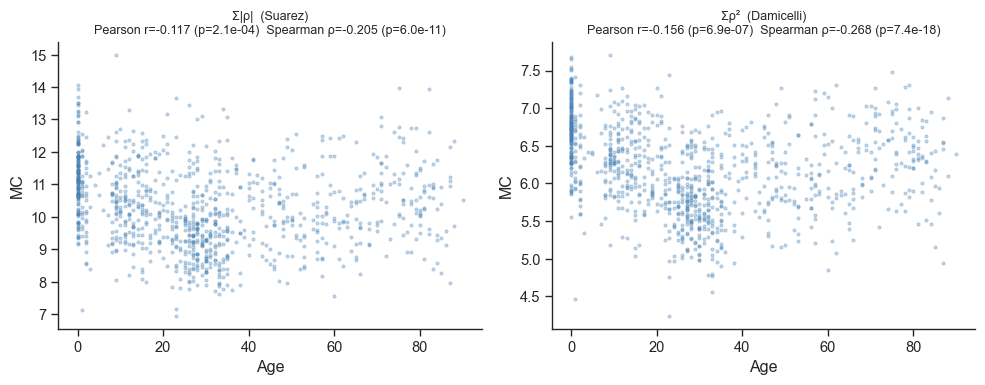

Correlation between Σ|ρ| and Σρ²: r = 0.9271

Σ|ρ|  — mean=10.284, std=1.255
Σρ²   — mean=6.179, std=0.575


In [65]:

from scipy.stats import pearsonr, spearmanr

df_test = pd.read_csv('ESNcpp/mc_simple_test.csv')
df_test=pd.merge(data, df_test, on='subject_id')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes,
                           ['MC_r', 'MC_r2'],
                           ['Σ|ρ|  (Suarez)', 'Σρ²  (Damicelli)']):
    ax.scatter(df_test['age'], df_test[col], s=5, alpha=0.3, color='steelblue')
    r_p, p_p = pearsonr(df_test['age'],  df_test[col])
    r_s, p_s = spearmanr(df_test['age'], df_test[col])
    ax.set_xlabel('Age')
    ax.set_ylabel('MC')
    ax.set_title(f'{label}\nPearson r={r_p:.3f} (p={p_p:.1e})  '
                 f'Spearman ρ={r_s:.3f} (p={p_s:.1e})', fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('results/ESN/mc_formula_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Correlation between the two metrics themselves
r_between, _ = pearsonr(df_test['MC_r'], df_test['MC_r2'])
print(f"Correlation between Σ|ρ| and Σρ²: r = {r_between:.4f}")
print(f"\nΣ|ρ|  — mean={df_test['MC_r'].mean():.3f}, std={df_test['MC_r'].std():.3f}")
print(f"Σρ²   — mean={df_test['MC_r2'].mean():.3f}, std={df_test['MC_r2'].std():.3f}")

# Legendre pols

In [31]:
"""
ipc_remerge.py  –  drop stale IPC columns and re-merge with the new CSV.
Run this ONCE to update df, then run ipc_cross_plot.py.
"""

import numpy as np
import pandas as pd

IPC_CSV = "ESNcpp/ipc_results.csv"

# ── Load new CSV ───────────────────────────────────────────────────────────────
df_ipc = pd.read_csv(IPC_CSV)
df_ipc = pd.merge(df_ipc, data, on='subject_id')



In [29]:
df_ipc.columns

Index(['subject_id', 'Lin_Glob', 'Quad_Glob', 'Cross11_Glob', 'Lin_Bio',
       'Quad_Bio', 'Cross11_Bio', 'Unnamed: 7', 'age', 'dataset', 'sex',
       'connectome', 'density', 'strength', 'degree', 'Y_obs', 'kY_obs',
       'Y_null', 'Ratio', 'weight', 'C_unw', 'C_w', 'comm_mean'],
      dtype='str')

5


/var/folders/7n/71x2ltnx73b7278bb830jrf80000gn/T/ipykernel_3973/3282548377.py:119: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "ipc_breakdown_lines.png", dpi=300,
/var/folders/7n/71x2ltnx73b7278bb830jrf80000gn/T/ipykernel_3973/3282548377.py:119: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "ipc_breakdown_lines.png", dpi=300,
/var/folders/7n/71x2ltnx73b7278bb830jrf80000gn/T/ipykernel_3973/3282548377.py:121: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "ipc_breakdown_lines.pdf", dpi=300,
/var/folders/7n/71x2ltnx73b7278bb830jrf80000gn/T/ipykernel_3973/3282548377.py:121: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "ipc_breakdown_lines.pdf", dpi=300,


Saved: ipc_breakdown_lines.{png,pdf}


/Users/alex/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alex/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


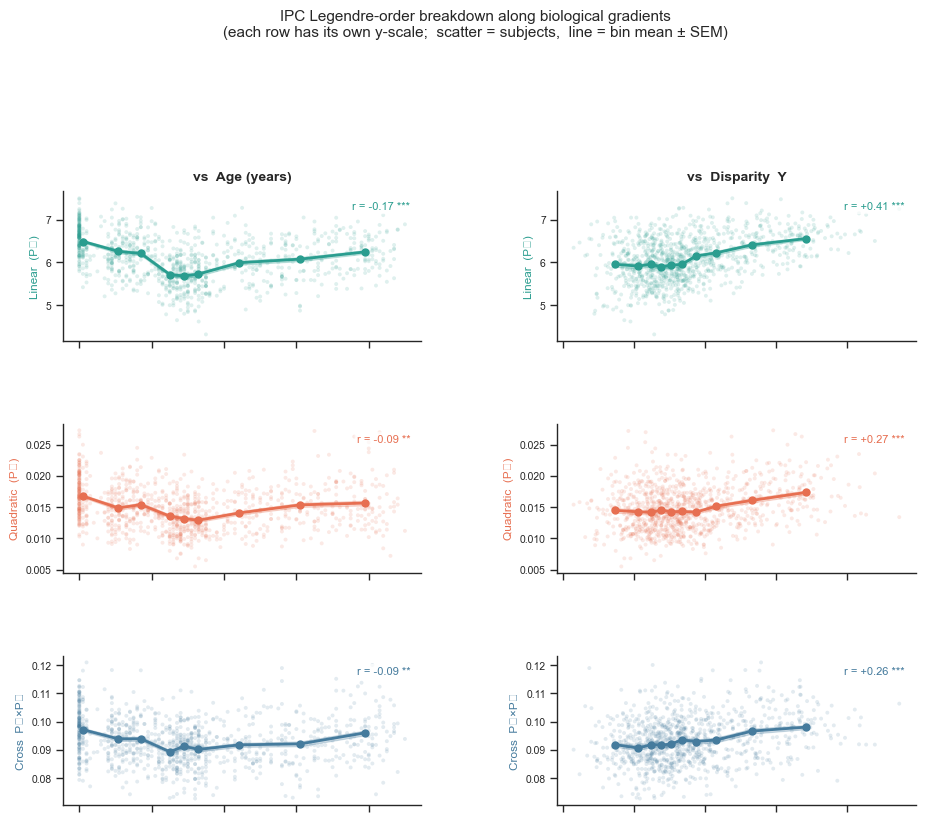


── Pearson r with age and disparity ──────────────────────────────
           term  r_age  p_age  r_Ratio  p_Ratio
   Linear  (P₁) -0.173  0.000    0.411      0.0
Quadratic  (P₂) -0.094  0.003    0.267      0.0
   Cross  P₁×P₁ -0.089  0.005    0.260      0.0


In [32]:
"""
ipc_breakdown.py
================
Line plot of each IPC term (+ total) vs age and vs disparity.
Each term gets its own y-axis scale (axes don't share y).
Grid: rows = IPC terms + total,  cols = age | disparity.

Requires `df` with: age, kY_obs, Lin_Glob, Quad_Glob,
                    Cross11_Glob, [Cross21_Glob, Cross22_Glob]
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr
from pathlib import Path

sns.set_theme(style="ticks", context="paper", font_scale=1.1)
OUT_DIR = Path("results/IPC")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Terms ──────────────────────────────────────────────────────────────────────
TERMS_ALL = {
    "Lin_Glob":    ("Linear  (P₁)",      "#2a9d8f"),
    "Quad_Glob":   ("Quadratic  (P₂)",   "#e76f51"),
    "Cross11_Glob":("Cross  P₁×P₁",      "#457b9d"),
    "Cross21_Glob":("Cross  P₂×P₁",      "#9b5de5"),
    "Cross22_Glob":("Cross  P₂×P₂",      "#f4a261"),
}
TERMS = {k: v for k, v in TERMS_ALL.items() if k in df_ipc.columns}
COLS  = list(TERMS)

# ── X-axes ────────────────────────────────────────────────────────────────────
X_AXES = {}
if "age" in df_ipc.columns:
    X_AXES["age"] = "Age (years)"
if "Ratio" in df_ipc.columns:
    X_AXES["Ratio"] = "Disparity  Υ"

N_BINS = 10
MIN_N  = 5

def bin_summary(df_, x_col):
    sub = df_[[x_col] + COLS].dropna().copy()
    sub["_bin"] = pd.qcut(sub[x_col], q=N_BINS, duplicates="drop")
    g = sub.groupby("_bin", observed=True)
    m = g[COLS].mean()
    s = g[COLS].sem()
    m["_x"] = g[x_col].mean()
    m["_n"] = g[x_col].count()
    keep = m["_n"] >= MIN_N
    m = m[keep].reset_index(drop=True)
    s = s[keep].reset_index(drop=True)
    return m, s

# ── Figure: rows = terms, cols = x-axes ───────────────────────────────────────
n_rows = len(TERMS_ALL)
n_cols = len(X_AXES)
FIG_W  = 5.5 * n_cols
FIG_H  = 2.8 * n_rows

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = gridspec.GridSpec(n_rows, n_cols, hspace=0.55, wspace=0.38)
print(n_rows)

for col_j, (x_col, x_label) in enumerate(X_AXES.items()):
    means, sems = bin_summary(df_ipc, x_col)
    xs = means["_x"].values

    for row_i, col in enumerate(COLS):
        label, color = TERMS[col]
        ax = fig.add_subplot(gs[row_i, col_j])

        y  = means[col].values
        se = sems[col].values

        # Scatter of individual subjects (faint)
        ax.scatter(df_ipc[x_col], df_ipc[col],
                   alpha=0.15, s=8, color=color, edgecolors="none", zorder=1)

        # Binned mean ± SEM
        ax.plot(xs, y, "o-", color=color, lw=2, ms=5, zorder=3)
        ax.fill_between(xs, y - se, y + se, color=color, alpha=0.25, zorder=2)

        # Pearson r annotation
        sub = df_ipc[[x_col, col]].dropna()
        r, p = pearsonr(sub[x_col], sub[col])
        sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        ax.text(0.97, 0.93, f"r = {r:+.2f} {sig}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, color=color,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

        # Labels — only outermost to avoid clutter
        if row_i == n_rows - 1:
            ax.set_xlabel(x_label, fontsize=9)
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([])

        # Each row gets its own y-scale (key request)
        ax.set_ylabel(label, fontsize=8.5, color=color)
        ax.tick_params(axis="y", labelsize=7.5)
        ax.tick_params(axis="x", labelsize=7.5)

        sns.despine(ax=ax)

        # Column title only on first row
        if row_i == 0:
            ax.set_title(f"vs  {x_label}", fontsize=10, fontweight="bold", pad=8)

plt.suptitle("IPC Legendre-order breakdown along biological gradients\n"
             "(each row has its own y-scale;  scatter = subjects,  line = bin mean ± SEM)",
             fontsize=11, y=1.01)

# FIXED: Save the figure before showing it
fig.savefig(OUT_DIR / "ipc_breakdown_lines.png", dpi=300,
            bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "ipc_breakdown_lines.pdf", dpi=300,
            bbox_inches="tight", transparent=True)

print("Saved: ipc_breakdown_lines.{png,pdf}")

# FIXED: Call plt.show() after saving
plt.show(block=True)

# ── Quick summary table ────────────────────────────────────────────────────────
print("\n── Pearson r with age and disparity ──────────────────────────────")
rows = []
for col in COLS:
    label = TERMS[col][0]
    row   = {"term": label}
    for x_col, x_label in X_AXES.items():
        sub = df_ipc[[x_col, col]].dropna()
        r, p = pearsonr(sub[x_col], sub[col])
        row[f"r_{x_col}"] = round(r, 3)
        row[f"p_{x_col}"] = round(p, 4)
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

# Surrogates

HAY MAS  DE UN SURROGATE! pero no puedo pintarlos todos

In [12]:

sns.set_theme(style="ticks", context="paper", font_scale=1.2)


# ── Colours ───────────────────────────────────────────────────────────────────
c_glob      = '#2a9d8f'
c_bio       = '#457b9d'
c_null_glob = '#a8dadc'
c_null_bio  = '#a8c5d8'
c_ratio_g   = '#555555'
c_ratio_b   = '#999999'
c_age       = '#e76f51'

# ── Bootstrap median + CI ────────────────────────────────────────────────────
def median_ci(x, n_boot=1000, ci=95):
    x = np.asarray(x)
    med = np.median(x)
    res = bootstrap((x,), np.median, n_resamples=n_boot,
                    confidence_level=ci/100, method='percentile')
    return med, res.confidence_interval.low, res.confidence_interval.high

def bin_median_ci(df, x_col, y_cols, q=10):
    df = df.copy()
    df['_bin'] = pd.qcut(df[x_col], q=q, duplicates='drop')
    rows = []
    for _, sub in df.groupby('_bin', observed=True):
        row = {x_col: sub[x_col].median()}
        for col in y_cols:
            med, lo, hi = median_ci(sub[col].dropna())
            row[col]         = med
            row[col + '_lo'] = lo
            row[col + '_hi'] = hi
        rows.append(row)
    return pd.DataFrame(rows)



In [141]:
df.columns

Index(['subject_id', 'MC_Glob_Real', 'MC_Glob_BS', 'Ratio_Glob_BS', 'MC_Bio_Real', 'MC_Bio_BS', 'Ratio_Bio_BS',
       'MC_Glob_Uni', 'Ratio_Glob_Uni', 'MC_Bio_Uni', 'Ratio_Bio_Uni', 'MC_Glob_Rsh', 'Ratio_Glob_Rsh', 'MC_Bio_Rsh',
       'Ratio_Bio_Rsh', 'age', 'dataset', 'sex', 'connectome', 'density', 'strength', 'degree', 'Y_obs', 'kY_obs',
       'Y_null', 'Ratio', 'weight', 'C_unw', 'C_w', 'comm_mean'],
      dtype='str')

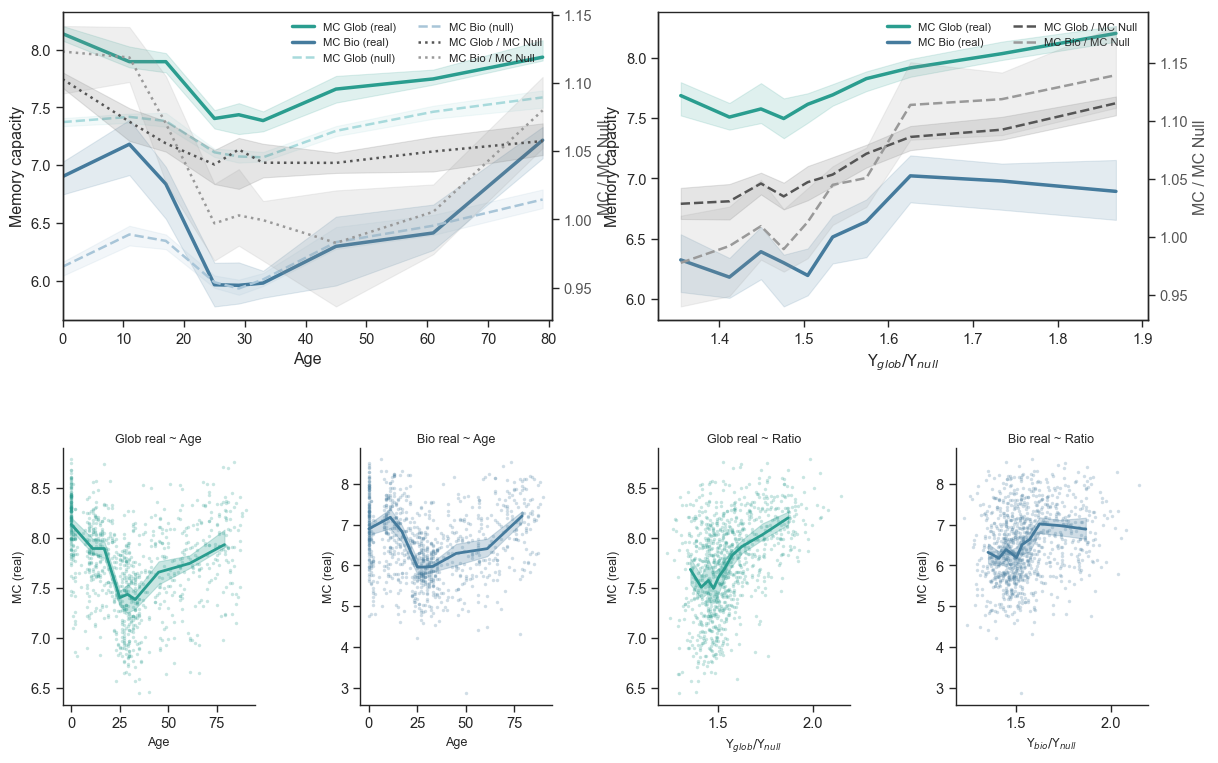

In [19]:

null_t = 'BS'  # suffix for null model columns (e.g. 'MC_Glob_BS')
# ── Bin trajectories ─────────────────────────────────────────────────────────
y_age_cols   = ['MC_Glob_Real', 'MC_Bio_Real', f'MC_Glob_{null_t}', f'MC_Bio_{null_t}',
                f'Ratio_Glob_{null_t}', f'Ratio_Bio_{null_t}']
y_ratio_cols = ['MC_Glob_Real', 'MC_Bio_Real', f'MC_Glob_{null_t}', f'MC_Bio_{null_t}', f'Ratio_Glob_{null_t}', f'Ratio_Bio_{null_t}', 'age']
traj_age   = bin_median_ci(df, 'age',       y_age_cols,   q=10)
traj_ratio = bin_median_ci(df, 'Ratio', y_ratio_cols, q=10)

# ── Helper: line + shaded CI ──────────────────────────────────────────────────
def lplot(ax, x, traj, col, color, label, ls='-', lw=2.5, alpha=0.15):
    ax.plot(x, traj[col], color=color, lw=lw, ls=ls, label=label)
    ax.fill_between(x, traj[col+'_lo'], traj[col+'_hi'], color=color, alpha=alpha)

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1], hspace=0.45, wspace=0.55)

# ─── Row 0-left: MC vs Age, Ratio on twin axis ────────────────────────────────
ax_l  = fig.add_subplot(gs[0, :2])
ax_l2 = ax_l.twinx()
x = traj_age['age']

lplot(ax_l,  x, traj_age, 'MC_Glob_Real',     c_glob,      'MC Glob (real)')
lplot(ax_l,  x, traj_age, 'MC_Bio_Real',       c_bio,       'MC Bio (real)')
lplot(ax_l,  x, traj_age, f'MC_Glob_{null_t}', c_null_glob, 'MC Glob (null)', ls='--', lw=1.8)
lplot(ax_l,  x, traj_age, f'MC_Bio_{null_t}',  c_null_bio,  'MC Bio (null)',  ls='--', lw=1.8)
lplot(ax_l2, x, traj_age, f'Ratio_Glob_{null_t}', c_ratio_g, r'MC Glob / MC Null', ls=':', lw=1.8)
lplot(ax_l2, x, traj_age, f'Ratio_Bio_{null_t}',  c_ratio_b, r'MC Bio / MC Null',  ls=':', lw=1.8)

ax_l.set_xlabel('Age');  ax_l.set_ylabel('Memory capacity')
ax_l2.set_ylabel(r'MC / MC Null', color=c_ratio_g)
ax_l2.tick_params(axis='y', labelcolor=c_ratio_g)
ax_l.set_xlim(x.min()*0.98, x.max()*1.02)
h1, l1 = ax_l.get_legend_handles_labels()
h2, l2 = ax_l2.get_legend_handles_labels()
ax_l.legend(h1+h2, l1+l2, frameon=False, fontsize=8, loc='upper right', ncol=2)
sns.despine(ax=ax_l, right=False)

# ─── Row 0-right: MC vs Ratio_Glob, Age on twin axis ─────────────────────────
ax_r  = fig.add_subplot(gs[0, 2:])
ax_r2 = ax_r.twinx()
x = traj_ratio['Ratio']

lplot(ax_r,  x, traj_ratio, 'MC_Glob_Real',     c_glob,      'MC Glob (real)')
lplot(ax_r,  x, traj_ratio, 'MC_Bio_Real',       c_bio,       'MC Bio (real)')
lplot(ax_r2,  x, traj_ratio, f'Ratio_Glob_{null_t}', c_ratio_g, r'MC Glob / MC Null', ls='--', lw=1.8)
lplot(ax_r2,  x, traj_ratio, f'Ratio_Bio_{null_t}',  c_ratio_b,  r'MC Bio / MC Null',  ls='--', lw=1.8)

ax_r.set_xlabel(r'$\Upsilon_{glob}/\Upsilon_{null}$');  ax_r.set_ylabel('Memory capacity')
ax_r2.set_ylabel('MC / MC Null', color=c_ratio_g);  ax_r2.tick_params(axis='y', labelcolor=c_ratio_g)
ax_r.set_xlim(x.min()*0.98, x.max()*1.02)
h1, l1 = ax_r.get_legend_handles_labels()
h2, l2 = ax_r2.get_legend_handles_labels()
ax_r.legend(h1+h2, l1+l2, frameon=False, fontsize=8, loc='upper right', ncol=2)
sns.despine(ax=ax_r, right=False)

# ─── Row 1: Scatter panels ────────────────────────────────────────────────────
scatter_cfg = [
    ('age',        'MC_Glob_Real', 'Age',                               'MC (real)', c_glob, 'Glob real ~ Age'),
    ('age',        'MC_Bio_Real',  'Age',                               'MC (real)', c_bio,  'Bio real ~ Age'),
    ('Ratio', 'MC_Glob_Real', r'$\Upsilon_{glob}/\Upsilon_{null}$','MC (real)', c_glob, 'Glob real ~ Ratio'),
    ('Ratio',  'MC_Bio_Real',  r'$\Upsilon_{bio}/\Upsilon_{null}$', 'MC (real)', c_bio,  'Bio real ~ Ratio'),
]

NULL_MAP = {          # real col → corresponding null col
    'MC_Glob_Real': 'MC_Glob_Null_Rand',
    'MC_Bio_Real':  'MC_Bio_Null_Rand',
}

for col_idx, (xcol, ycol, xlabel, ylabel, color, title) in enumerate(scatter_cfg):
    ax = fig.add_subplot(gs[1, col_idx])
    ax.scatter(df[xcol], df[ycol], s=6, alpha=0.25, color=color, linewidths=0)

    null_col = NULL_MAP.get(ycol)
    if null_col and null_col in df.columns:
        ax.scatter(df[xcol], df[null_col], s=6, alpha=0.15,
                   color='#bbbbbb', linewidths=0, label='Null')

    traj_s = bin_median_ci(df, xcol, [ycol], q=10)
    ax.plot(traj_s[xcol], traj_s[ycol], color=color, lw=2, zorder=5)
    ax.fill_between(traj_s[xcol], traj_s[ycol+'_lo'], traj_s[ycol+'_hi'],
                    color=color, alpha=0.25, zorder=4)

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9, pad=4)
    sns.despine(ax=ax)

import os; os.makedirs('results/ESN', exist_ok=True)
plt.savefig('results/ESN/mc_disparity_age.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

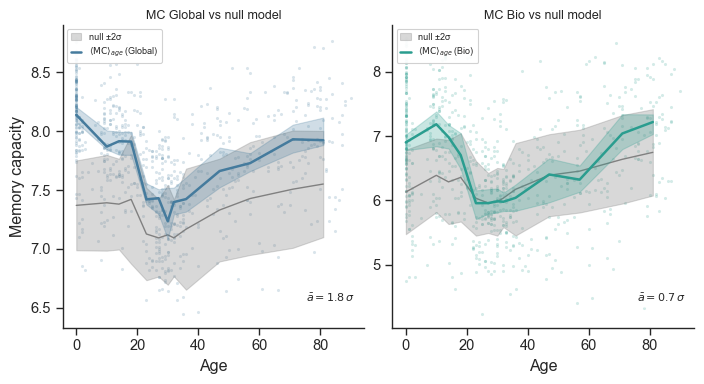

In [26]:


sns.set_theme(style="ticks", context="paper", font_scale=1.2)


RES_SIZE = 90        # theoretical max MC (reservoir size) — heterogeneous analog
c_glob   = '#457b9d'
c_bio    = '#2a9d8f'
c_null   = 'grey'
c_het    = '#cc0000'
rng_fig  = np.random.default_rng(42)

# ── Binned stats ──────────────────────────────────────────────────────────────
def bin_obs(df, x_col, y_col, q=15):
    """Median ± bootstrap CI of y_col, binned by x_col."""
    df = df.copy()
    df['_bin'] = pd.qcut(df[x_col], q=q, duplicates='drop')
    rows = []
    for _, sub in df.groupby('_bin', observed=True):
        vals = sub[y_col].dropna().values
        med  = np.median(vals)
        boot = np.array([np.median(rng_fig.choice(vals, len(vals))) for _ in range(1000)])
        rows.append({x_col: sub[x_col].median(),
                     'med': med,
                     'lo':  np.percentile(boot, 2.5),
                     'hi':  np.percentile(boot, 97.5)})
    return pd.DataFrame(rows)

def bin_null(df, x_col, null_col, q=15):
    """Mean ± 2σ of null values across subjects within each age bin."""
    df = df.copy()
    df['_bin'] = pd.qcut(df[x_col], q=q, duplicates='drop')
    rows = []
    for _, sub in df.groupby('_bin', observed=True):
        vals = sub[null_col].dropna().values
        mu   = vals.mean()
        sig  = vals.std(ddof=1) if len(vals) > 1 else 0.0
        rows.append({x_col: sub[x_col].median(),
                     'mu': mu,
                     'lo': mu - 2 * sig,
                     'hi': mu + 2 * sig})
    return pd.DataFrame(rows)

# ── Panel config ──────────────────────────────────────────────────────────────
panels = [
    ('MC_Glob_Real', f'MC_Glob_{null_t}', c_glob, 'Global'),
    ('MC_Bio_Real',  f'MC_Bio_{null_t}',  c_bio,  'Bio'),
]

fig, axes = plt.subplots(1, 2, figsize=(7, 3.8))

for ax, (real_col, null_col, color, label) in zip(axes, panels):

    obs = bin_obs(df,  'age', real_col, q=15)
    nul = bin_null(df, 'age', null_col, q=15)

    # ── scatter (subsampled) ──────────────────────────────────────────────────
    idx = rng_fig.choice(len(df), min(800, len(df)), replace=False)
    ax.scatter(df['age'].iloc[idx], df[real_col].iloc[idx],
               s=5, alpha=0.20, color=color, linewidths=0,
               rasterized=True, zorder=1)

    # ── null band ─────────────────────────────────────────────────────────────
    ax.fill_between(nul['age'], nul['lo'], nul['hi'],
                    color=c_null, alpha=0.30, zorder=2, label='null ±2σ')
    ax.plot(nul['age'], nul['mu'], '-', color=c_null, lw=1, zorder=3)


    # ── observed mean line + CI ───────────────────────────────────────────────
    ax.plot(obs['age'], obs['med'], '-', color=color, lw=1.8, zorder=5,
            label=rf'$\langle\mathrm{{MC}}\rangle_{{age}}$ ({label})')
    ax.fill_between(obs['age'], obs['lo'], obs['hi'],
                    color=color, alpha=0.25, zorder=4)

    # ── ā annotation (σ above null) ───────────────────────────────────────────
    null_sig = (nul['hi'] - nul['mu']) / 2
    a_vals   = (obs['med'].values - nul['mu'].values) / null_sig.values
    a_mean   = np.nanmean(a_vals[null_sig.values > 0])
    ax.text(0.97, 0.08, rf'$\bar{{a}} = {a_mean:.1f}\,\sigma$',
            transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

    ax.set_xlabel('Age')
    ax.set_ylabel('Memory capacity' if ax is axes[0] else '')
    ax.set_title(f'MC {label} vs null model', fontsize=9, pad=4)
    ax.legend(fontsize=6.5, handlelength=1.2, loc='upper left', framealpha=0.9)
    sns.despine(ax=ax)

plt.tight_layout(pad=0.5)
os.makedirs('results/ESN', exist_ok=True)
plt.savefig('results/ESN/mc_null_scatter.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

## Thalamic input null

/var/folders/7n/71x2ltnx73b7278bb830jrf80000gn/T/ipykernel_40226/2092338792.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Condition', y='MC', order=order,


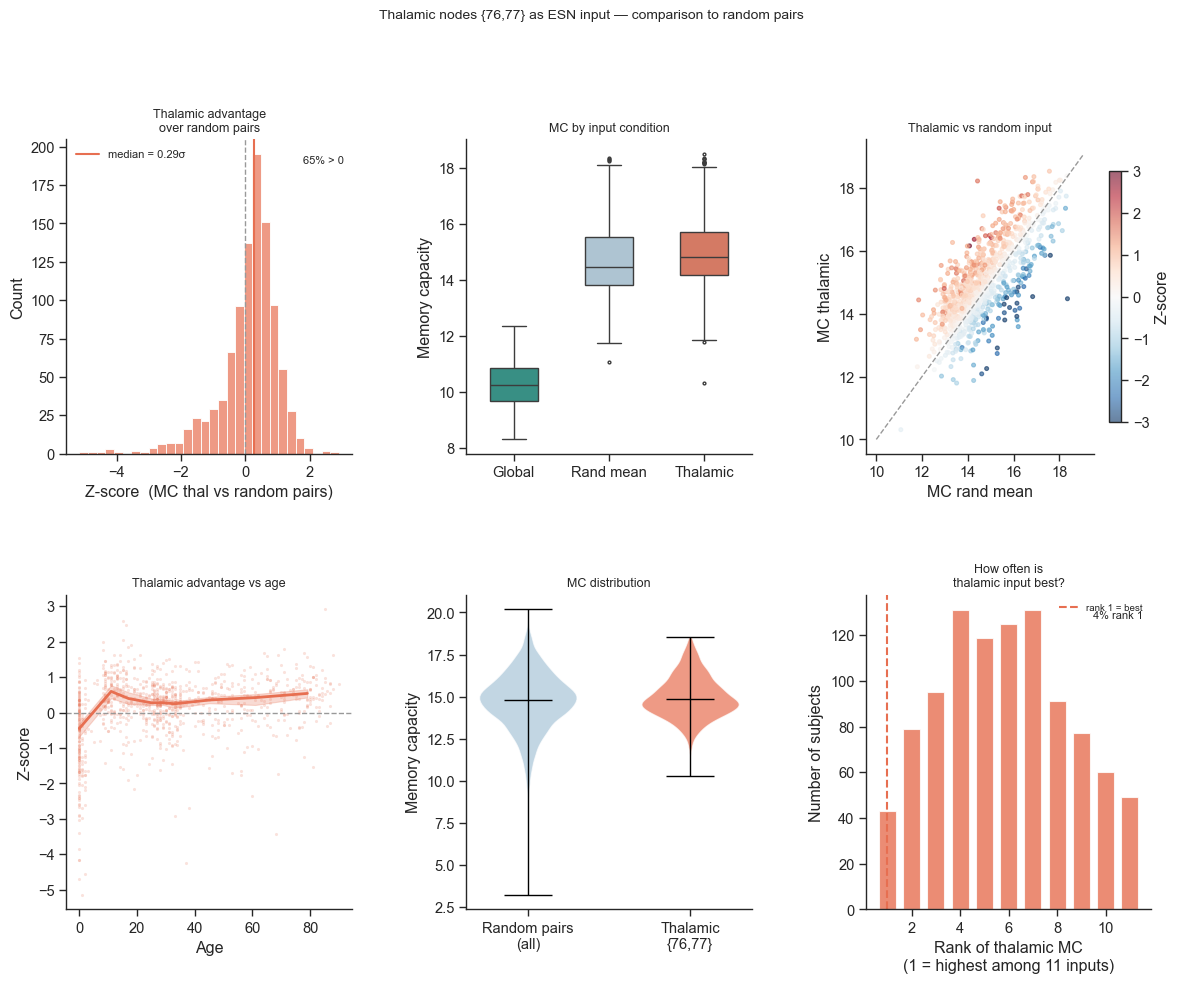

Subjects: 1000
MC_Thal   mean ± std : 14.990 ± 1.234
MC_Rand   mean ± std : 14.700 ± 1.261
MC_Glob   mean ± std : 10.282 ± 0.772
Z-score   mean ± std : 0.110 ± 0.928
% subjects Z > 0     : 65.4%
% subjects rank 1    : 4.3%
Z-score ~ age        : r=0.275, p=9.496e-19


In [31]:
# ── Load thalamic results & merge ─────────────────────────────────────────────
df_thal  = pd.read_csv('ESNcpp/mc_thalamic_results.csv')
df_pairs = pd.read_csv('ESNcpp/mc_thalamic_pairs.csv')

df_thal = pd.merge(df_thal, data, on='subject_id')

# ── Identify random-pair MC columns ──────────────────────────────────────────
rand_cols = [c for c in df_thal.columns if c.startswith('MC_Rand_0') or c.startswith('MC_Rand_')]
rand_cols = sorted([c for c in rand_cols if c not in ('MC_Rand_Mean', 'MC_Rand_Std')])

# ── Colours ───────────────────────────────────────────────────────────────────
c_thal  = '#e76f51'
c_rand  = '#a8c5d8'
c_glob  = '#2a9d8f'
c_zero  = '#999999'

sns.set_theme(style='ticks', context='paper', font_scale=1.2)

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 1 — Overview: is thalamic MC special?
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# ── 1A: Z-score distribution ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.axvline(0, color=c_zero, lw=1, ls='--')
ax.axvline(df_thal['Z_Score'].median(), color=c_thal, lw=1.5, ls='-',
           label=f"median = {df_thal['Z_Score'].median():.2f}σ")
sns.histplot(df_thal['Z_Score'], bins=30, color=c_thal, alpha=0.7, ax=ax)
ax.set_xlabel('Z-score  (MC thal vs random pairs)')
ax.set_ylabel('Count')
ax.set_title('Thalamic advantage\nover random pairs', fontsize=9)
ax.legend(fontsize=8, frameon=False)
pct_above = (df_thal['Z_Score'] > 0).mean() * 100
ax.text(0.97, 0.95, f'{pct_above:.0f}% > 0',
        transform=ax.transAxes, ha='right', va='top', fontsize=8)
sns.despine(ax=ax)

# ── 1B: Paired comparison — thal vs rand_mean vs glob ────────────────────────
ax = fig.add_subplot(gs[0, 1])
plot_df = pd.DataFrame({
    'Global':   df_thal['MC_Glob'],
    'Thalamic': df_thal['MC_Thal'],
    'Rand mean':df_thal['MC_Rand_Mean'],
}).melt(var_name='Condition', value_name='MC')

order = ['Global', 'Rand mean', 'Thalamic']
palette = {'Global': c_glob, 'Rand mean': c_rand, 'Thalamic': c_thal}
sns.boxplot(data=plot_df, x='Condition', y='MC', order=order,
            palette=palette, width=0.5, fliersize=2, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Memory capacity')
ax.set_title('MC by input condition', fontsize=9)
sns.despine(ax=ax)

# ── 1C: MC_Thal vs MC_Rand_Mean scatter, coloured by Z-score ─────────────────
ax = fig.add_subplot(gs[0, 2])
sc = ax.scatter(df_thal['MC_Rand_Mean'], df_thal['MC_Thal'],
                c=df_thal['Z_Score'], cmap='RdBu_r', s=8, alpha=0.6,
                vmin=-3, vmax=3)
lim_lo = min(df_thal['MC_Rand_Mean'].min(), df_thal['MC_Thal'].min()) * 0.97
lim_hi = max(df_thal['MC_Rand_Mean'].max(), df_thal['MC_Thal'].max()) * 1.03
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], '--', color=c_zero, lw=1)
plt.colorbar(sc, ax=ax, label='Z-score', shrink=0.8)
ax.set_xlabel('MC rand mean')
ax.set_ylabel('MC thalamic')
ax.set_title('Thalamic vs random input', fontsize=9)
sns.despine(ax=ax)

# ── 2A: Z-score vs age ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])

def bin_median_ci(d, xcol, ycol, q=10):
    d = d.copy()
    d['_b'] = pd.qcut(d[xcol], q=q, duplicates='drop')
    rows = []
    for _, s in d.groupby('_b', observed=True):
        v = s[ycol].dropna().values
        med  = np.median(v)
        boot = np.array([np.median(np.random.choice(v, len(v))) for _ in range(500)])
        rows.append({xcol: s[xcol].median(), 'med': med,
                     'lo': np.percentile(boot, 2.5),
                     'hi': np.percentile(boot, 97.5)})
    return pd.DataFrame(rows)

ax.axhline(0, color=c_zero, lw=1, ls='--')
ax.scatter(df_thal['age'], df_thal['Z_Score'],
           s=5, alpha=0.2, color=c_thal, linewidths=0)
tr = bin_median_ci(df_thal, 'age', 'Z_Score', q=10)
ax.plot(tr['age'], tr['med'], color=c_thal, lw=2)
ax.fill_between(tr['age'], tr['lo'], tr['hi'], color=c_thal, alpha=0.25)
ax.set_xlabel('Age')
ax.set_ylabel('Z-score')
ax.set_title('Thalamic advantage vs age', fontsize=9)
sns.despine(ax=ax)

# ── 2B: Full distribution — thal vs all random pairs (raincloud style) ───────
ax = fig.add_subplot(gs[1, 1])

# Stack all random pair MC values into long form
rand_long = df_thal[rand_cols].values.flatten()
thal_vals = df_thal['MC_Thal'].values

parts = ax.violinplot([rand_long, thal_vals], positions=[0, 1],
                      showmedians=True, widths=0.6)
for i, (pc, col) in enumerate(zip(parts['bodies'], [c_rand, c_thal])):
    pc.set_facecolor(col); pc.set_alpha(0.7)
for key in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
    parts[key].set_color('black'); parts[key].set_linewidth(1)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Random pairs\n(all)', 'Thalamic\n{76,77}'])
ax.set_ylabel('Memory capacity')
ax.set_title('MC distribution', fontsize=9)
sns.despine(ax=ax)

# ── 2C: Per-subject rank of thalamic MC among all pairs ──────────────────────
ax = fig.add_subplot(gs[1, 2])
n_pairs = len(rand_cols)

def thal_rank(row):
    """Rank of MC_Thal among [rand_00..rand_N, thal]: 1 = highest."""
    all_vals = np.append([row[c] for c in rand_cols], row['MC_Thal'])
    return (all_vals > row['MC_Thal']).sum() + 1   # how many beat it

df_thal['thal_rank'] = df_thal.apply(thal_rank, axis=1)
rank_counts = df_thal['thal_rank'].value_counts().sort_index()
ax.bar(rank_counts.index, rank_counts.values, color=c_thal, alpha=0.8, width=0.7)
ax.axvline(1, color=c_thal, lw=1.5, ls='--', label='rank 1 = best')
ax.set_xlabel(f'Rank of thalamic MC\n(1 = highest among {n_pairs+1} inputs)')
ax.set_ylabel('Number of subjects')
ax.set_title('How often is\nthalamic input best?', fontsize=9)
pct_rank1 = (df_thal['thal_rank'] == 1).mean() * 100
ax.text(0.97, 0.95, f'{pct_rank1:.0f}% rank 1',
        transform=ax.transAxes, ha='right', va='top', fontsize=8)
ax.legend(fontsize=7, frameon=False)
sns.despine(ax=ax)

plt.suptitle('Thalamic nodes {76,77} as ESN input — comparison to random pairs',
             fontsize=10, y=1.01)
plt.savefig('results/ESN/mc_thalamic_analysis.pdf',
            bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"Subjects: {len(df_thal)}")
print(f"MC_Thal   mean ± std : {df_thal['MC_Thal'].mean():.3f} ± {df_thal['MC_Thal'].std():.3f}")
print(f"MC_Rand   mean ± std : {df_thal['MC_Rand_Mean'].mean():.3f} ± {df_thal['MC_Rand_Mean'].std():.3f}")
print(f"MC_Glob   mean ± std : {df_thal['MC_Glob'].mean():.3f} ± {df_thal['MC_Glob'].std():.3f}")
print(f"Z-score   mean ± std : {df_thal['Z_Score'].mean():.3f} ± {df_thal['Z_Score'].std():.3f}")
print(f"% subjects Z > 0     : {(df_thal['Z_Score'] > 0).mean()*100:.1f}%")
print(f"% subjects rank 1    : {(df_thal['thal_rank'] == 1).mean()*100:.1f}%")
r, p = pearsonr(df_thal['age'], df_thal['Z_Score'])
print(f"Z-score ~ age        : r={r:.3f}, p={p:.3e}")

# PCA UMAP

/Users/alex/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/alex/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


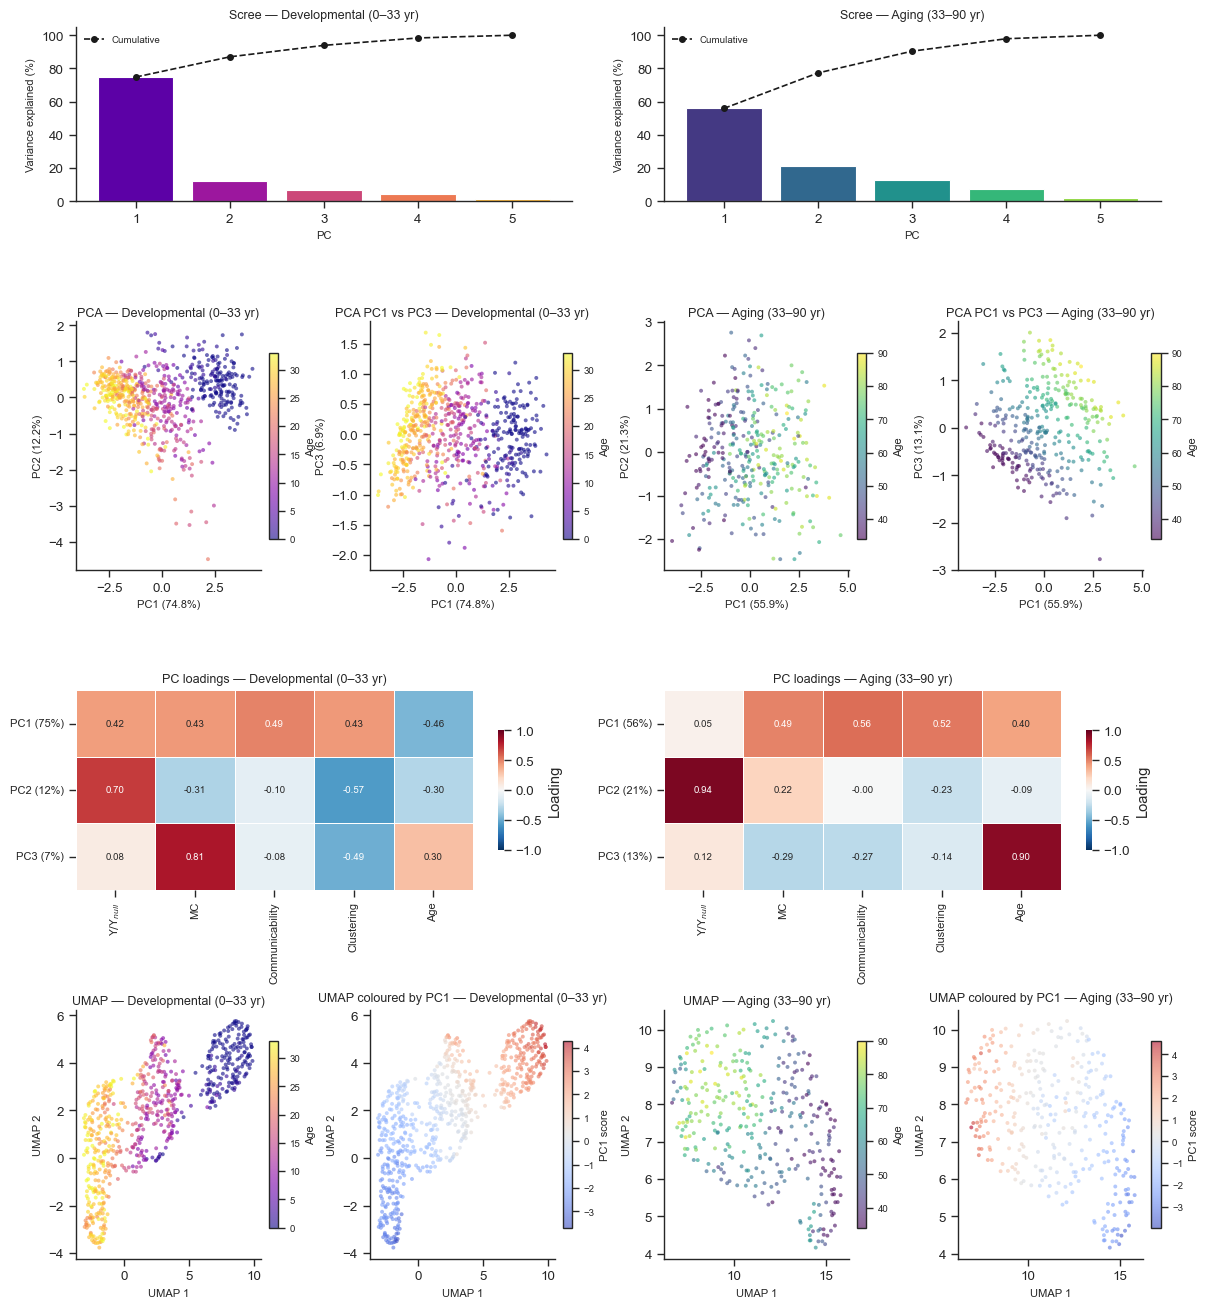


── PC correlations with MC_Glob_Real ──

Developmental (0–33 yr)
  PC1: r=0.839, p=1.13e-178
  PC2: r=-0.239, p=3.97e-10
  PC3: r=0.478, p=1.58e-39
  PC4: r=-0.091, p=1.80e-02
  PC5: r=-0.039, p=3.11e-01

Aging (33–90 yr)
  PC1: r=0.828, p=1.30e-84
  PC2: r=0.227, p=3.14e-05
  PC3: r=-0.232, p=2.06e-05
  PC4: r=0.447, p=1.14e-17
  PC5: r=-0.098, p=7.38e-02


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap  # pip install umap-learn

sns.set_theme(style="ticks", context="paper", font_scale=1.1)

# ── Config ────────────────────────────────────────────────────────────────────
AGE_SPLIT   = 33          # developmental < 33 ≤ aging
FEATURES    = ['Ratio', 'MC_Glob_Real', 'comm_mean', 'C_w', 'age']
FEAT_LABELS = [r'$\Upsilon/\Upsilon_{null}$', 'MC', 'Communicability', 'Clustering', 'Age']
UMAP_PARAMS = dict(n_neighbors=30, min_dist=0.3, n_components=2, random_state=42)

COHORTS = {
    'Developmental (0–33 yr)': df[df['age'] <= AGE_SPLIT].copy(),
    'Aging (33–90 yr)':        df[df['age'] >  AGE_SPLIT].copy(),
}
COHORT_CMAPS = ['plasma', 'viridis']

# ── Helpers ───────────────────────────────────────────────────────────────────
def run_pca(sub):
    X = sub[FEATURES].dropna()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=len(FEATURES))
    coords = pca.fit_transform(Xs)
    return pca, coords, X.index

def run_umap(sub):
    X = sub[FEATURES].dropna()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    reducer = umap.UMAP(**UMAP_PARAMS)
    coords = reducer.fit_transform(Xs)
    return coords, X.index

def scatter_embed(ax, coords, ages, cmap, title, xlabel, ylabel):
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=ages, cmap=cmap, s=8, alpha=0.6, linewidths=0)
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Age', fontsize=8)
    cb.ax.tick_params(labelsize=7)
    ax.set_title(title, fontsize=9, pad=4)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    sns.despine(ax=ax)

# ── Figure layout ─────────────────────────────────────────────────────────────
# Row 0: scree plots (one per cohort)
# Row 1: PCA biplots coloured by age
# Row 2: PCA loadings heatmaps
# Row 3: UMAP embeddings coloured by age

n_cohorts = len(COHORTS)
fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, n_cohorts * 2,
                        height_ratios=[0.7, 1, 0.8, 1],
                        hspace=0.55, wspace=0.45)

for ci, ((label, sub), cmap) in enumerate(zip(COHORTS.items(), COHORT_CMAPS)):
    ages = sub['age']
    col_base = ci * 2   # each cohort occupies 2 columns

    # ── PCA ───────────────────────────────────────────────────────────────────
    pca, pca_coords, idx = run_pca(sub)
    ages_pca = sub.loc[idx, 'age'].values
    ev = pca.explained_variance_ratio_ * 100

    # Scree (row 0, spans 2 cols per cohort)
    ax_scree = fig.add_subplot(gs[0, col_base:col_base+2])
    bars = ax_scree.bar(range(1, len(FEATURES)+1), ev,
                        color=sns.color_palette(cmap, len(FEATURES)))
    ax_scree.plot(range(1, len(FEATURES)+1), np.cumsum(ev),
                  'k--', lw=1.2, marker='o', ms=4, label='Cumulative')
    ax_scree.set_xticks(range(1, len(FEATURES)+1))
    ax_scree.set_xlabel('PC', fontsize=8)
    ax_scree.set_ylabel('Variance explained (%)', fontsize=8)
    ax_scree.set_title(f'Scree — {label}', fontsize=9)
    ax_scree.legend(frameon=False, fontsize=7)
    ax_scree.set_ylim(0, 105)
    sns.despine(ax=ax_scree)

    # PCA biplot PC1 vs PC2 (row 1, left col of pair)
    ax_pca = fig.add_subplot(gs[1, col_base])
    scatter_embed(ax_pca, pca_coords[:, :2], ages_pca, cmap,
                  f'PCA — {label}',
                  f'PC1 ({ev[0]:.1f}%)', f'PC2 ({ev[1]:.1f}%)')

    # PCA biplot PC1 vs PC3 (row 1, right col of pair)
    ax_pca2 = fig.add_subplot(gs[1, col_base+1])
    scatter_embed(ax_pca2,
                  np.column_stack([pca_coords[:, 0], pca_coords[:, 2]]),
                  ages_pca, cmap,
                  f'PCA PC1 vs PC3 — {label}',
                  f'PC1 ({ev[0]:.1f}%)', f'PC3 ({ev[2]:.1f}%)')

    # Loadings heatmap (row 2, spans 2 cols)
    ax_load = fig.add_subplot(gs[2, col_base:col_base+2])
    loadings = pd.DataFrame(
        pca.components_[:3, :],
        index=[f'PC{i+1} ({ev[i]:.0f}%)' for i in range(3)],
        columns=FEAT_LABELS
    )
    sns.heatmap(loadings, ax=ax_load, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, annot=True, fmt='.2f',
                annot_kws={'size': 7}, linewidths=0.4,
                cbar_kws={'shrink': 0.6, 'label': 'Loading'})
    ax_load.set_title(f'PC loadings — {label}', fontsize=9)
    ax_load.tick_params(axis='x', labelsize=8)
    ax_load.tick_params(axis='y', labelsize=8, rotation=0)

    # ── UMAP ──────────────────────────────────────────────────────────────────
    umap_coords, idx_u = run_umap(sub)
    ages_umap = sub.loc[idx_u, 'age'].values

    # UMAP left (row 3, left col)
    ax_umap = fig.add_subplot(gs[3, col_base])
    scatter_embed(ax_umap, umap_coords, ages_umap, cmap,
                  f'UMAP — {label}', 'UMAP 1', 'UMAP 2')

    # UMAP right: colour by PC1 score to link PCA and UMAP
    ax_umap2 = fig.add_subplot(gs[3, col_base+1])
    pc1_scores = pca_coords[np.isin(idx, idx_u), 0]
    sc2 = ax_umap2.scatter(umap_coords[:, 0], umap_coords[:, 1],
                           c=pc1_scores, cmap='coolwarm',
                           s=8, alpha=0.6, linewidths=0)
    cb2 = plt.colorbar(sc2, ax=ax_umap2, fraction=0.046, pad=0.04)
    cb2.set_label('PC1 score', fontsize=8)
    cb2.ax.tick_params(labelsize=7)
    ax_umap2.set_title(f'UMAP coloured by PC1 — {label}', fontsize=9)
    ax_umap2.set_xlabel('UMAP 1', fontsize=8)
    ax_umap2.set_ylabel('UMAP 2', fontsize=8)
    sns.despine(ax=ax_umap2)

plt.savefig('results/ESN/pca_umap.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# ── Print PC-feature correlations with MC ────────────────────────────────────
print("\n── PC correlations with MC_Glob_Real ──")
from scipy.stats import pearsonr
for label, sub in COHORTS.items():
    pca, pca_coords, idx = run_pca(sub)
    mc = sub.loc[idx, 'MC_Glob_Real'].values
    print(f"\n{label}")
    for pc_i in range(len(FEATURES)):
        r, p = pearsonr(pca_coords[:, pc_i], mc)
        print(f"  PC{pc_i+1}: r={r:.3f}, p={p:.2e}")

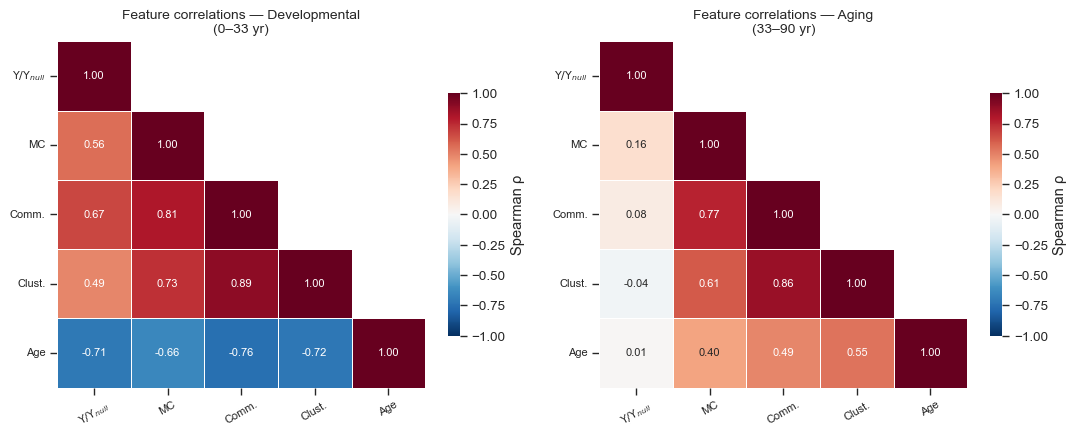

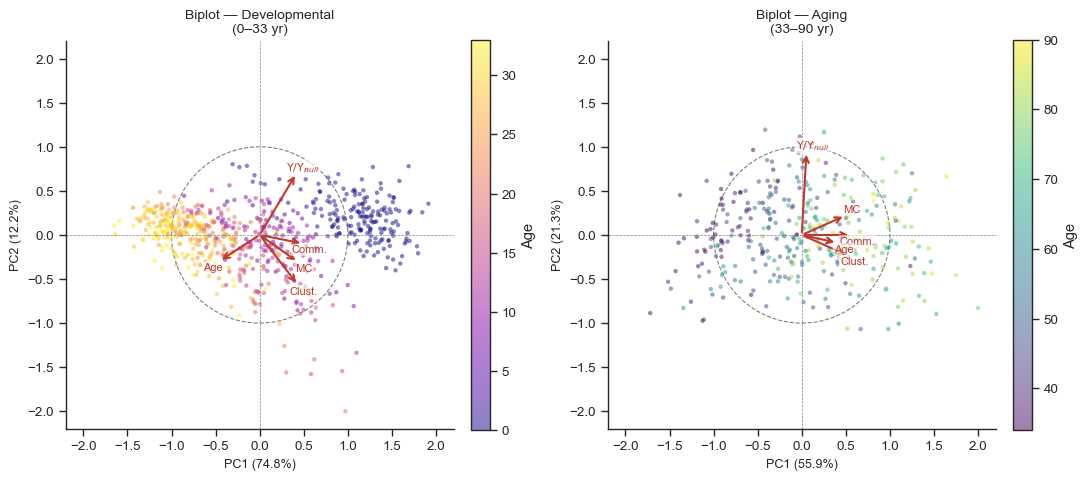

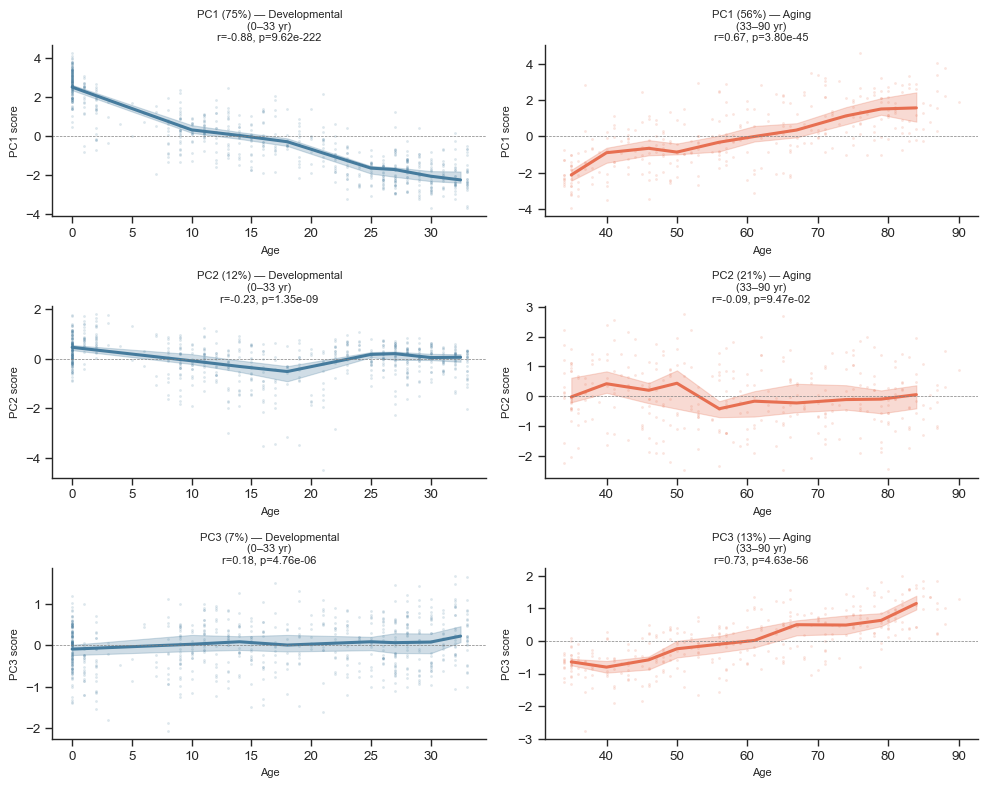

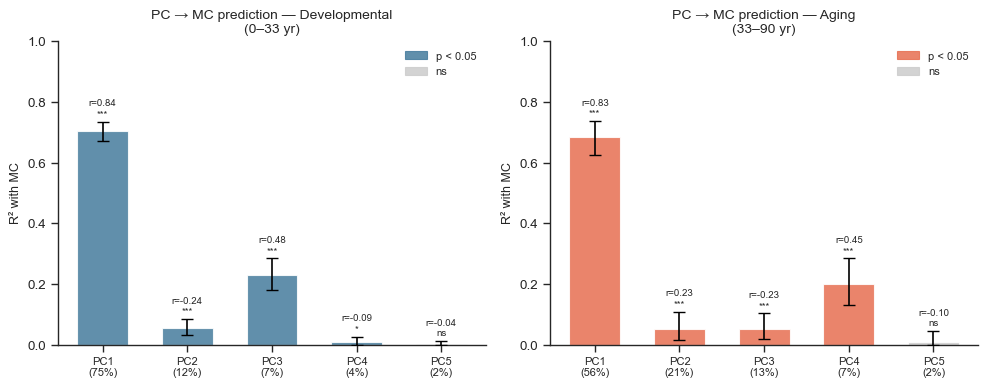


── Spearman ρ: PC scores vs MC_Glob_Real ──

Developmental
(0–33 yr)
  PC        EV%       r      R²          p
  PC1     74.8%   0.839   0.704  1.13e-178
  PC2     12.2%  -0.239   0.057   3.97e-10
  PC3      6.9%   0.478   0.229   1.58e-39
  PC4      4.5%  -0.091   0.008   1.80e-02
  PC5      1.6%  -0.039   0.002   3.11e-01

Aging
(33–90 yr)
  PC        EV%       r      R²          p
  PC1     55.9%   0.828   0.685   1.30e-84
  PC2     21.3%   0.227   0.051   3.14e-05
  PC3     13.1%  -0.232   0.054   2.06e-05
  PC4      7.5%   0.447   0.200   1.14e-17
  PC5      2.1%  -0.098   0.010   7.38e-02


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
from scipy.stats import bootstrap

sns.set_theme(style="ticks", context="paper", font_scale=1.1)

FEATURES    = ['Ratio', 'MC_Glob_Real', 'comm_mean', 'C_w', 'age']
FEAT_LABELS = [r'$\Upsilon/\Upsilon_{null}$', 'MC', 'Comm.', 'Clust.', 'Age']
AGE_SPLIT   = 33
COHORTS = {
    'Developmental\n(0–33 yr)': df[df['age'] <= AGE_SPLIT].copy(),
    'Aging\n(33–90 yr)':        df[df['age'] >  AGE_SPLIT].copy(),
}
COLORS = {'Developmental\n(0–33 yr)': '#457b9d', 'Aging\n(33–90 yr)': '#e76f51'}

def fit_pca(sub):
    X = sub[FEATURES].dropna()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=len(FEATURES))
    coords = pca.fit_transform(Xs)
    ev = pca.explained_variance_ratio_ * 100
    return pca, coords, X.index, ev, scaler

def median_ci(x, n_boot=500):
    x = np.asarray(x)
    res = bootstrap((x,), np.median, n_resamples=n_boot,
                    confidence_level=0.95, method='percentile')
    return np.median(x), res.confidence_interval.low, res.confidence_interval.high

def bin_stat(x, y, q=10):
    df_tmp = pd.DataFrame({'x': x, 'y': y})
    df_tmp['bin'] = pd.qcut(df_tmp['x'], q=q, duplicates='drop')
    rows = []
    for _, g in df_tmp.groupby('bin', observed=True):
        m, lo, hi = median_ci(g['y'].dropna())
        rows.append({'xc': g['x'].median(), 'med': m, 'lo': lo, 'hi': hi})
    return pd.DataFrame(rows)

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 1 – Feature correlation matrix (before PCA)
# Understand what PCA is actually compressing
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (label, sub) in zip(axes, COHORTS.items()):
    corr = sub[FEATURES].corr(method='spearman')
    corr.columns = FEAT_LABELS
    corr.index   = FEAT_LABELS
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=ax, mask=mask, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, annot=True, fmt='.2f',
                annot_kws={'size': 8}, linewidths=0.5,
                cbar_kws={'shrink': 0.7, 'label': "Spearman ρ"})
    ax.set_title(f'Feature correlations — {label.strip()}', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('results/ESN/pca_feat_corr.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 2 – Classic biplot (PC1 vs PC2 + loading arrows)
# Arrows show direction & magnitude of each feature in PC space
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (label, sub), cmap in zip(axes, COHORTS.items(), ['plasma', 'viridis']):
    pca, coords, idx, ev, _ = fit_pca(sub)
    ages = sub.loc[idx, 'age'].values

    # Scale coords to [-2,2] for visual alignment with arrows
    scale = max(np.abs(coords[:, 0]).max(), np.abs(coords[:, 1]).max())
    xs = coords[:, 0] / scale * 2
    ys = coords[:, 1] / scale * 2

    sc = ax.scatter(xs, ys, c=ages, cmap=cmap, s=10, alpha=0.5,
                    linewidths=0, zorder=2)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label='Age')

    # Loading arrows — scale to unit circle
    arrow_scale = 1.0
    for j, fname in enumerate(FEAT_LABELS):
        lx = pca.components_[0, j] * arrow_scale
        ly = pca.components_[1, j] * arrow_scale
        ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))
        offset_x = 0.07 * np.sign(lx) + lx
        offset_y = 0.07 * np.sign(ly) + ly
        ax.text(offset_x, offset_y, fname, fontsize=8,
                color='#c0392b', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none'))

    circle = plt.Circle((0, 0), 1, color='gray', fill=False, lw=0.8, ls='--')
    ax.add_patch(circle)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)', fontsize=9)
    ax.set_title(f'Biplot — {label.strip()}', fontsize=10)
    ax.set_aspect('equal')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('results/ESN/pca_biplot.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 3 – PC scores vs age trajectories
# How does each PC evolve across the lifespan within each cohort?
# ═══════════════════════════════════════════════════════════════════════════════
N_PCS = 3
fig, axes = plt.subplots(N_PCS, 2, figsize=(10, 8), sharey=False)
for ci, (label, sub) in enumerate(COHORTS.items()):
    pca, coords, idx, ev, _ = fit_pca(sub)
    ages = sub.loc[idx, 'age'].values
    color = list(COLORS.values())[ci]
    for pc_i in range(N_PCS):
        ax = axes[pc_i, ci]
        traj = bin_stat(ages, coords[:, pc_i], q=10)
        ax.scatter(ages, coords[:, pc_i], s=4, alpha=0.18,
                   color=color, linewidths=0)
        ax.plot(traj['xc'], traj['med'], color=color, lw=2.2)
        ax.fill_between(traj['xc'], traj['lo'], traj['hi'],
                        color=color, alpha=0.25)
        r, p = pearsonr(ages, coords[:, pc_i])
        ax.set_title(f'PC{pc_i+1} ({ev[pc_i]:.0f}%) — {label.strip()}\n'
                     f'r={r:.2f}, p={p:.2e}', fontsize=8, pad=3)
        ax.set_xlabel('Age', fontsize=8)
        ax.set_ylabel(f'PC{pc_i+1} score', fontsize=8)
        ax.axhline(0, color='gray', lw=0.5, ls='--')
        sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('results/ESN/pca_scores_age.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 4 – Which PCs predict MC?
# Ridge-style bar chart of R² for PC_i ~ MC, with bootstrap CI
# This is the key interpretive result: the axis of connectome variation
# that matters computationally
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
for ax, (label, sub), color in zip(axes, COHORTS.items(), COLORS.values()):
    pca, coords, idx, ev, _ = fit_pca(sub)
    mc = sub.loc[idx, 'MC_Glob_Real'].values

    rs, ps, r2s, r2_lo, r2_hi = [], [], [], [], []
    for pc_i in range(len(FEATURES)):
        r, p = pearsonr(coords[:, pc_i], mc)
        rs.append(r); ps.append(p); r2s.append(r**2)
        def r2_boot(x, y=coords[:, pc_i], mc_=mc):
            return pearsonr(y[list(x)], mc_[list(x)])[0] ** 2
        boot = bootstrap(
            (np.arange(len(mc)),), r2_boot,
            n_resamples=500, method='percentile', confidence_level=0.95
        )
        r2_lo.append(boot.confidence_interval.low)
        r2_hi.append(boot.confidence_interval.high)

    x_pos = np.arange(len(FEATURES))
    bars = ax.bar(x_pos, r2s, color=[color if p < 0.05 else '#cccccc' for p in ps],
                  alpha=0.85, width=0.6, zorder=2)
    ax.errorbar(x_pos, r2s,
                yerr=[np.array(r2s)-np.array(r2_lo),
                      np.array(r2_hi)-np.array(r2s)],
                fmt='none', color='black', capsize=4, lw=1.2, zorder=3)

    # Annotate r values
    for xi, (r, p) in enumerate(zip(rs, ps)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.text(xi, r2s[xi] + r2_hi[xi] - r2s[xi] + 0.01,
                f'r={r:.2f}\n{sig}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'PC{i+1}\n({ev[i]:.0f}%)' for i in range(len(FEATURES))],
                       fontsize=8)
    ax.set_ylabel('R² with MC', fontsize=9)
    ax.set_title(f'PC → MC prediction — {label.strip()}', fontsize=10)
    ax.set_ylim(0, min(1.0, max(r2_hi) * 1.5))
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, color=color,   alpha=0.85, label='p < 0.05'),
        plt.Rectangle((0,0),1,1, color='#cccccc', alpha=0.85, label='ns'),
    ], frameon=False, fontsize=8, loc='upper right')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('results/ESN/pca_mc_prediction.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── Spearman ρ: PC scores vs MC_Glob_Real ──")
for label, sub in COHORTS.items():
    pca, coords, idx, ev, _ = fit_pca(sub)
    mc = sub.loc[idx, 'MC_Glob_Real'].values
    print(f"\n{label.strip()}")
    print(f"  {'PC':<6} {'EV%':>6} {'r':>7} {'R²':>7} {'p':>10}")
    for pc_i in range(len(FEATURES)):
        r, p = pearsonr(coords[:, pc_i], mc)
        print(f"  PC{pc_i+1:<4} {ev[pc_i]:>5.1f}% {r:>7.3f} {r**2:>7.3f} {p:>10.2e}")

# Todo

- Avg sobre distintas Win realiztions (suarez hace 1000, yo 1)
- Asegurarme ridge regression. 
- Quizás puedo capar tau values antes que subir a 90. quizás podría cortar cuando solo sume un 1% pero este 1% tendria que estar promediado en realizaciones.... mejor capar a 20.


# IA suggestions


### 0.2 MC metric: |r| not r² — consistent with Suárez et al., inconsistent with Rodriguez et al.

In `Math.cpp`, `CalculateMemoryCapacity` accumulates `std::abs(rho)`, i.e. `|r|`:

```cpp
memory_capacity += std::abs(rho);
```

Suárez et al. also use `|r|` (their Eq. 4, p. 781: "sum across time lags of the *absolute* correlation"). Rodriguez et al. use r² (coefficient of determination, their Eq. 5, p. 562). Your choice is consistent with Suárez et al. but you must be explicit about this in Methods, since the two conventions give different numerical ranges and the comparison to Rodriguez et al. values is not direct.

Check
---

## 1. How your implementation compares to Suárez et al. (2021)

### 1.1 What matches

| Feature | Suárez et al. | Your code |
|---|---|---|
| Activation function | tanh | tanh (`std::tanh`, `ESN.cpp` line ~`new_state[i] = std::tanh(sum)`) |
| Leaking rate | α=1 (fixed) | α=1 (commented explicitly in `ESN.cpp`) |
| Readout | Linear (ridge regression) | Ridge, λ=1e-4 (`Math.cpp::TrainReadout`) |
| MC metric | Σ|r| | Σ|r| (`Math.cpp::CalculateMemoryCapacity`) |
| Input nodes | Subcortical (all 15) or thalamus | Global (random Win) or thalamic (nodes 76,77) |
| Bias node | Implied in readout | Explicit bias column in `X_train` (`Math.cpp`, lines ~75–79) |

The tanh + α=1 choice means your code is in the same dynamical regime as Suárez et al. This is consistent and correct.

### 1.2 Key differences that affect interpretation

**Spectral radius: fixed vs. swept.**  
Suárez et al. swept α ∈ [0.3, 3.5] across 15 values and showed that the biological topology advantage is *exclusively at criticality* (α≈1). Your code fixes `spectral_radius = 0.99` for all connectomes (`Multitask.cpp`, `esn.rescaleReservoir(0.99)`). This means:

- You are always near criticality, which is where biological topology matters most — a reasonable choice for a single operating point.
- You cannot observe the regime-dependent sign-flip of correlations that Suárez et al. found (Fig. 6, p. 778): node strength is positively correlated with MC in the stable regime but negatively in the chaotic regime. Since all your results are at one α, you are blind to this interaction.
- Since you fix α by rescaling W *before* running the reservoir, every connectome gets the same spectral radius regardless of its original weight distribution. This effectively normalizes out global weight scale — which is good for isolating topology, but means you cannot study the effect of weight scale changes across age (which your draft Fig. 1 shows are real). This is both a limitation and an advantage: you are measuring topology, not weight scale.

**Number of reservoir realizations: 1 vs. 1000.**  
Suárez et al. used 1000 bootstrap resamples of participant connectivity matrices to build confidence intervals. Rodriguez et al. averaged over 64 reservoir samples. Your code uses a single ESN per connectome (fixed seed `rng{42}`). This means:

- Each age × task data point has no error bars.
- Variance across connectomes within an age group is treated as signal (which it may be), but you cannot distinguish it from initialization noise.
- At minimum, you should run each connectome 3–5 times with different random `Win` initializations and average MC. The reservoir weights W are set from the connectome (fixed), but Win is random; its realization affects MC non-trivially.

**Training set size: 400 samples, 91 free parameters.**  
With `size_input=1000`, `washout=100`, `train_ratio=0.5`: effective training set = 1000×0.5 − 100 = 400 samples. The readout has `reservoir_size + 1 = 91` parameters (90 nodes + bias). The samples-to-parameters ratio is ~4.4, which is tight. Ridge regression with λ=1e-4 is very weak regularization for this ratio — consider increasing to λ=1e-2 or λ=1e-1 and verifying that training vs. test performance tracks well.

**Tau range: 20 vs. 16.**  
Your `tau_vals=20`, Suárez et al. used τ ∈ [1,16]. A longer lag window is better for detecting age-related changes in MC if older/younger connectomes differ in how far back they can remember, but it also accumulates more near-zero r values that add noise to the MC sum. Check whether the bulk of your MC comes from τ=1–5 (fast memory) or from longer lags.

---

## 2. How your implementation compares to Rodriguez et al. (2019)

Rodriguez et al. used threshold-like neurons (a steep sigmoid, their Eq. 3, p. 561), **not tanh**. Their key finding — that modularity optimally gates information flow — is specific to threshold-like (complex contagion) dynamics and does not hold for tanh reservoirs (Rodriguez et al., Discussion, p. 559: "the optimal modularity phenomenon emerges only for neural networks of threshold-like neurons and does not exist for neural networks of linear or tanh neurons").

**Implication:** Your current code cannot reproduce or leverage the Rodriguez et al. mechanism. The `std::tanh` in `ESN.cpp::EvoluteReservoir` places you in the Suárez et al. framework, where the relevant structural predictors of MC are node strength and clustering coefficient (Suárez et al., Fig. 6a), *not* modularity or disparity per se. If you want to use Rodriguez et al. as a mechanistic backbone for why disparity matters, you need to add a threshold-like activation option:

```cpp
// Optional: threshold-like activation (Rodriguez et al. Eq. 3)
double sigmoid_thresh(double z) {
    return 1.0 / (1.0 + std::exp(-10.0 * (z - 1.0)));
}
```

and show that the disparity–MC relationship strengthens under this activation relative to tanh.

---

## 4. What the correlation results tell us given the implementation

Given that:
- Spectral radius is fixed at 0.99 (near-critical)
- tanh activation (Suárez et al. regime)
- Input is either global (random Win) or thalamic (nodes 76–77)
- MC is Σ|r| over τ=1..20

The Pearson correlations between age and task metrics shown in your bar plot (r up to ±0.6 for age < 30) should be interpreted as follows:

**Linear Memory (negative r with age):** MC decreases with age in the development cohort. Since spectral radius is fixed, this means the *topology* of younger connectomes supports stronger echo-state dynamics even at the same α. This is consistent with Suárez et al.'s finding that topology — specifically intrinsic network structure — drives MC at criticality. The sign is surprising (younger = better MC) and worth examining: does it hold because young connectomes have shorter characteristic path lengths, or higher clustering?


## 5. Structural metric to ESN performance pipeline — concrete recommendations

Given your code, here is the concrete pipeline for connecting disparity to MC:

**Step 1 — Fix the disparity formula** (Section 0.1 above). Recompute disparity for all GREP connectomes.

**Step 2 — Compute disparity per connectome in C++, export alongside MC.** Add a column to `task_results.txt`:

```cpp
double disp = esn_1D_g.calculateDisparity(connectomes[i]);  // after fix
outfile << format("{},{:.4f},...,{:.4f}", ages[i], mc_g, ..., disp);
```

**Step 3 — Compute standard graph metrics for each connectome in Python** (modularity, clustering, participation coefficient, characteristic path length — as in Suárez et al. Fig. 6). Use `networkx` or `bctpy`.

**Step 4 — Partial regression in Python:**

```python
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

# Predict MC from [disparity, modularity, clustering, density, age]
# Then check partial r of disparity after controlling for others
```

If disparity has non-zero partial correlation with MC after controlling for density, degree, and modularity, you have a genuine new finding. If not, disparity is redundant with known predictors.

**Step 5 — Weight ablation test.** For a subset of connectomes, shuffle the weights while keeping the binarized adjacency structure (preserving which connections exist but homogenizing weights → low disparity). Run the same ESN pipeline. If MC drops, weight heterogeneity causally matters. This requires only adding a function in C++ or Python:

```python
def shuffle_weights(W):
    adj = (W != 0)
    weights = W[adj]
    np.random.shuffle(weights)
    W_shuffled = np.zeros_like(W)
    W_shuffled[adj] = weights
    return W_shuffled
```

---

## 6. Priority action list (revised from code review)

| Priority | Action | Blocking? |
|---|---|---|
| **1** | Fix disparity formula in `ESN.cpp::calculateDisparity` | Yes — all disparity results are currently wrong |
| **2** | Verify AAL90 hemisphere ordering for Multitask split (nodes 0–44 vs. 45–89) | Yes — Multitask result may be meaningless |
| **3** | Add Win realization averaging (3–5 seeds per connectome) | Yes — single realization adds unquantified variance |
| **4** | Check NARMA predictions for overflow/divergence | Yes — may explain saturation |
| **5** | Construct GREPs per (age × dataset), not age alone | High — removes dataset confound |
| **6** | Increase ridge λ from 1e-4 to 1e-2 or sweep it | Medium — prevents overfitting with 400 samples |
| **7** | Export disparity + standard graph metrics alongside task results | High — needed for partial correlation analysis |
| **8** | Add thalamic input null model (2 random nodes, not 76–77) | High — needed to validate thalamic claim |
| **9** | Sweep τ distribution: check how much MC comes from τ>10 | Medium — affects interpretation of age–MC correlation |
| **10** | Add threshold-like activation option to `ESN.cpp` | Low — only needed if pursuing Rodriguez et al. framework |

---

## References

- Suárez, L. E., Richards, B. A., Lajoie, G., & Misic, B. (2021). Learning function from structure in neuromorphic networks. *Nature Machine Intelligence*, 3, 771–786. — MC formula: Eq. 4, p. 781; graph metrics vs. MC: Fig. 6, p. 778; thalamic sensitivity: p. 778 and Suppl. Figs. 5–6; topology advantage at criticality: Fig. 2, pp. 772–774.

- Rodriguez, N., Izquierdo, E., & Ahn, Y.-Y. (2019). Optimal modularity and memory capacity of neural reservoirs. *Network Neuroscience*, 3(2), 551–566. — Activation function requirement: Discussion, p. 559; MC formula (r²): Methods Eq. 5, p. 562; weight scale dominance: p. 556; community gating mechanism: Results pp. 554–557.

- Serrano, M. Á., Boguñá, M., & Vespignani, A. (2009). Extracting the multiscale backbone of complex weighted networks. *PNAS*, 106(16), 6483–6488. — Disparity formula: Eq. 1 (your draft p. 1).

- Betzel, R. F., Griffa, A., Hagmann, P., & Misic, B. (2019). Distance-dependent consensus thresholds for generating group-representative structural brain networks. *Network Neuroscience*, 3, 475–496.

# Methods: Echo State Network

## Reservoir Architecture

We implemented a connectome-informed Echo State Network (ESN) following the framework introduced by Suárez et al. (2021) and the general reservoir computing paradigm of Lukoševičius & Jaeger (2009). In this framework, the empirical structural connectome serves directly as the reservoir weight matrix **W** ∈ ℝ^{N×N}, where N = 90 corresponds to the number of cortical regions in the AAL90 atlas. No random reservoir is generated; the connectivity is fixed and determined entirely by the subject's (or group representative's) structural connectivity matrix derived from diffusion MRI tractography.

The reservoir state evolves according to the discrete-time equation:

$$\mathbf{x}(t+1) = \tanh\!\left(\mathbf{W}\,\mathbf{x}(t) + \mathbf{W}^{\mathrm{in}}\,\mathbf{u}(t+1)\right)$$

where **x**(t) ∈ ℝ^N is the reservoir state vector at time t, **u**(t) ∈ ℝ^K is the external input signal, and **W**^{in} ∈ ℝ^{N×K} is the input weight matrix. The hyperbolic tangent activation function is used throughout, consistent with Suárez et al. (2021). The leaking rate is fixed at α = 1 (no leakage), following Damicelli et al. (2022) and Suárez et al. (2021), so that any temporal memory in the reservoir arises exclusively from the recurrent topology of the connectome rather than from node-level inertia. The reservoir state is initialized to **x**(0) = **0**.

## Spectral Radius Normalization

Prior to running any task, the reservoir weight matrix is rescaled so that its spectral radius — the modulus of the largest eigenvalue — equals a target value of ρ(**W**) = 0.99. This places the reservoir at the edge of the stable dynamical regime, near the critical point (α ≈ 1) at which empirical brain connectomes have been shown to exhibit maximal and topology-dependent memory capacity (Suárez et al., 2021, Fig. 2). The rescaling is performed as:

$$\mathbf{W} \leftarrow \frac{0.99}{\rho(\mathbf{W}_0)}\,\mathbf{W}_0$$

where **W**₀ is the original connectivity matrix with weights normalized between 0 and 1, and ρ(**W**₀) is its spectral radius computed via full eigendecomposition. This normalization factorizes the effect of global weight scale from the effect of network topology, so that differences in ESN performance across connectomes reflect structural organization rather than differences in overall connectivity strength.

## Input Configuration

We tested two biologically motivated input configurations for each task.

**Global input.** The input weight matrix **W**^{in} ∈ ℝ^{N×K} is initialized with entries drawn independently from a uniform distribution U(−1, 1), projecting the input signal onto all N reservoir nodes with random weights. This configuration is agnostic to neuroanatomy and serves as a baseline.

**Thalamic input.** To approximate the role of the thalamus as the primary relay station for ascending sensory signals to the cortex (Sherman & Guillery, 2002), input was restricted to the left and right thalamic nodes of the AAL90 atlas (node indices 76 and 77). Non-zero input weights were assigned only to these nodes, again drawn from U(−1, 1), while all other entries of **W**^{in} were set to zero. For two-dimensional input tasks, the left thalamic node received the first input channel and the right thalamic node received the second. This mirrors the sensitivity analysis of Suárez et al. (2021), in which thalamic-only input was shown to yield at least as strong a topology-dependent memory advantage as full subcortical input.

## Readout and Training

The readout is a linear model trained to approximate a task-specific target signal y(t) from the reservoir states:

$$\hat{y}(t) = \mathbf{W}^{\mathrm{out}}\,[\mathbf{x}(t)\,;\,1]$$

where the semicolon denotes concatenation with a constant bias term. The readout weight vector **W**^{out} is estimated by ridge regression (Tikhonov regularization):

$$\mathbf{W}^{\mathrm{out}} = \left(\mathbf{X}^\top\mathbf{X} + \lambda\,\mathbf{I}\right)^{-1}\mathbf{X}^\top\mathbf{y}$$

with regularization parameter λ = 10⁻⁴. The linear system is solved via column-pivot Householder QR decomposition for numerical stability.

Each experiment uses T = 1000 time steps. The first 100 steps are discarded as a washout period to eliminate transient dynamics. Of the remaining 900 steps, the first 50% (400 steps) are used for training and the second 50% (500 steps) for testing. Readout weights are trained on the training segment and performance is evaluated exclusively on the held-out test segment.

## Tasks

We evaluated each connectome on six tasks that probe complementary computational properties of the reservoir.

**Linear Memory Capacity (MC).** Following Jaeger (2002) and Suárez et al. (2021), the reservoir receives a univariate input signal u(t) ~ U(−1, 1) and a set of τ_max = 20 independent linear readouts are trained to reproduce delayed copies of the input at lags τ = 1, …, 20. Memory capacity is defined as the sum of absolute Pearson correlations between predicted and true delayed signals across all lags:

$$\mathrm{MC} = \sum_{\tau=1}^{20} \left|\rho\!\left(u(t-\tau),\,\hat{y}_\tau(t)\right)\right|$$

Higher MC indicates that the reservoir retains more information about its input history.

**NARMA10.** A nonlinear autoregressive moving-average task of order 10 (Atiya & Parlos, 2000). The target signal is generated by the recurrence:

$$y(t+1) = 0.3\,y(t) + 0.05\,y(t)\sum_{i=0}^{9}y(t-i) + 1.5\,u(t-9)\,u(t) + 0.1$$

with u(t) ~ U(0, 0.5). Performance is measured by the Normalized Root Mean Square Error (NRMSE) on the test segment:

$$\mathrm{NRMSE} = \sqrt{\frac{\mathrm{MSE}}{\sigma_y^2}}$$

where σ²_y is the variance of the target signal. Lower NRMSE indicates better performance; a value of 1.0 corresponds to predicting the mean (chance level).

**Spatial Multitask.** Two independent input channels u₁(t), u₂(t) ~ U(−1, 1) are injected simultaneously (via the two thalamic nodes in the biological condition, or via random global weights for the two channels in the global condition). Two spatially segregated readout populations — corresponding to the left hemisphere (nodes 0–44) and right hemisphere (nodes 45–89) of AAL90 — are each trained independently to recall one of the two signals with a delay of 5 time steps. Performance is the mean NRMSE across the two readout populations. This task probes the capacity of the connectome to simultaneously segregate and process two concurrent input streams, a hallmark of hemispheric lateralization.

**Hub Integration.** Two independent input signals u₁(t), u₂(t) ~ U(0, 1) are injected into the reservoir and a single global readout is trained to predict their nonlinear product at a delay of 5 time steps:

$$y(t) = u_1(t-5)\cdot u_2(t-5)$$

This task requires both delayed integration across time and nonlinear mixing across input channels, probing the integrative function of putative hub nodes in the connectome. Performance is measured by NRMSE.

**Timescale Separation.** A single input u(t) ~ U(−1, 1) is presented and the target is the sum of the signal at two very different delays:

$$y(t) = u(t-1) + u(t-15)$$

A single global readout must learn to simultaneously represent a fast (τ = 1) and a slow (τ = 15) component of the input history, testing whether the connectome supports a heterogeneous distribution of effective timescales across its nodes. Performance is measured by NRMSE.

**Fast Product.** A single input u(t) ~ U(−1, 1) and the target is the product of two consecutive past inputs:

$$y(t) = u(t-1)\cdot u(t-2)$$

This task exclusively rewards fast, high-frequency nonlinear computation with minimal temporal depth, penalizing reservoirs with excessive hysteresis. Performance is measured by NRMSE.

## Statistical Analysis

For each connectome, all tasks were run under both global and thalamic input conditions, yielding 12 performance metrics per subject (or group representative). To assess the relationship between age and computational performance, Pearson correlation coefficients were computed between age and each metric across the sample. Significance was assessed under the null hypothesis of zero correlation. Analyses were performed separately for the developmental cohort (age < 30 years) and the aging cohort (age > 30 years) to account for the non-monotonic trajectory of brain maturation across the lifespan.

---

*Software.* The ESN was implemented in C++ using the Eigen 3 library for linear algebra (Guennebaud et al., 2010). Statistical analysis and visualization were performed in Python using SciPy, pandas, and seaborn.

---

## References (this section)

- Suárez, L. E., Richards, B. A., Lajoie, G., & Misic, B. (2021). Learning function from structure in neuromorphic networks. *Nature Machine Intelligence*, 3, 771–786.
- Lukoševičius, M., & Jaeger, H. (2009). Reservoir computing approaches to recurrent neural network training. *Computer Science Review*, 3(3), 127–149.
- Jaeger, H. (2002). Short term memory in echo state networks. *GMD Report*, 152.
- Atiya, A. F., & Parlos, A. G. (2000). New results on recurrent network training. *IEEE Transactions on Neural Networks*, 11(3), 697–709.
- Sherman, S. M., & Guillery, R. (2002). The role of the thalamus in the flow of information to the cortex. *Philosophical Transactions of the Royal Society B*, 357, 1695–1708.
- Damicelli, F., Hilgetag, C. C., & Goulas, A. (2022). Brain connectivity meets reservoir computing. *PLOS Computational Biology*, 18(11), e1010639.
- Guennebaud, G., Jacob, B., et al. (2010). Eigen v3. http://eigen.tuxfamily.org.